# Crypto Trading Bot — AI/ML Upgraded Edition
**By Shivam (ZORO)** | Strategy: RSI + SMC/ICT + LSTM + Sentiment + WebSockets

> Run Cell 0 first every time to install packages and load credentials.

In [36]:
# CELL 0 — INSTALL & SECURE SETUP
# ─────────────────────────────────────────────────────────────
# All credentials live in a .env file — NEVER hardcode passwords.
# Create a file called  .env  in the same folder as this notebook:
#
#   GMAIL_ADDRESS=your@gmail.com
#   GMAIL_APP_PASSWORD=xxxx xxxx xxxx xxxx
#   BINANCE_API_KEY=        (optional, for paper trading later)
#   BINANCE_SECRET_KEY=     (optional)
#
# Get a Gmail App Password at:
#   myaccount.google.com → Security → 2-Step Verification → App Passwords
# ─────────────────────────────────────────────────────────────

!pip install -q yfinance pandas numpy matplotlib seaborn plotly scipy \
              tensorflow scikit-learn vaderSentiment python-dotenv \
              websockets requests

import os, warnings, asyncio, json, time
from datetime import datetime
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import yfinance as yf
import pytz
from dotenv import load_dotenv

warnings.filterwarnings('ignore')
load_dotenv()  # reads .env file automatically

# ── Credentials (from .env, never hardcoded) ──
GMAIL_ADDRESS      = os.getenv("GMAIL_ADDRESS", "")
GMAIL_APP_PASSWORD = os.getenv("GMAIL_APP_PASSWORD", "")

if not GMAIL_ADDRESS or not GMAIL_APP_PASSWORD:
    print("⚠️  No .env credentials found — email alerts will be skipped.")
    print("   Create a .env file (see instructions above) to enable alerts.")
else:
    print(f"✅ Credentials loaded for {GMAIL_ADDRESS}")

# ── Config ──
class Config:
    CRYPTO_SYMBOLS   = ['ETH-USD', 'BTC-USD']
    PRIMARY_SYMBOL   = 'ETH-USD'
    PERIOD           = '180d'          # extended from 60d → 180d for better ML training
    INTERVAL         = '1h'
    INITIAL_CAPITAL  = 10_000
    RSI_PERIOD       = 14
    RSI_OVERSOLD     = 30
    RSI_OVERBOUGHT   = 70
    INDIA_TZ         = pytz.timezone('Asia/Kolkata')

config = Config()
print("✅ CELL 0 DONE — packages installed, config ready.")


✅ Credentials loaded for singhshivams1986@gmail.com
✅ CELL 0 DONE — packages installed, config ready.



[notice] A new release of pip is available: 25.3 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


## Cell 1 — Data Fetching & Technical Indicators
Fetches 180 days of hourly data and calculates RSI, MACD, Bollinger Bands, ATR, and volume features used by both the rule-based strategy and the LSTM model.

In [37]:
# CELL 1 — DATA FETCH + FEATURE ENGINEERING
# ─────────────────────────────────────────────────────────────

def fetch_crypto_data(symbol):
    print(f"  Downloading {symbol}...")
    ticker = yf.Ticker(symbol)
    data   = ticker.history(period=config.PERIOD, interval=config.INTERVAL)
    if data.empty:
        print(f"  ❌ No data for {symbol}")
        return None

    c = data['Close']

    # RSI
    delta = c.diff()
    gain  = delta.where(delta > 0, 0).rolling(14).mean()
    loss  = (-delta.where(delta < 0, 0)).rolling(14).mean()
    data['RSI'] = 100 - (100 / (1 + gain / loss))

    # Bollinger Bands
    data['BB_Middle'] = c.rolling(20).mean()
    bb_std            = c.rolling(20).std()
    data['BB_Upper']  = data['BB_Middle'] + 2 * bb_std
    data['BB_Lower']  = data['BB_Middle'] - 2 * bb_std
    data['BB_Width']  = (data['BB_Upper'] - data['BB_Lower']) / data['BB_Middle']

    # MACD
    ema12         = c.ewm(span=12).mean()
    ema26         = c.ewm(span=26).mean()
    data['MACD']        = ema12 - ema26
    data['MACD_Signal'] = data['MACD'].ewm(span=9).mean()
    data['MACD_Hist']   = data['MACD'] - data['MACD_Signal']

    # ATR (Average True Range) — key for position sizing
    hl  = data['High'] - data['Low']
    hpc = (data['High'] - c.shift()).abs()
    lpc = (data['Low']  - c.shift()).abs()
    data['ATR'] = pd.concat([hl, hpc, lpc], axis=1).max(axis=1).rolling(14).mean()

    # SMA & momentum
    data['SMA_20']      = c.rolling(20).mean()
    data['SMA_50']      = c.rolling(50).mean()
    data['Daily_Return']= c.pct_change()
    data['Momentum']    = c - c.shift(10)

    # Volume ratio vs 20-period average
    data['Volume_Ratio'] = data['Volume'] / data['Volume'].rolling(20).mean()

    data = data.bfill().ffill()
    print(f"  ✅ {symbol}: {len(data)} rows, columns: {list(data.columns)}")
    return data

print("🔄 Fetching data...")
crypto_data = {}
for sym in config.CRYPTO_SYMBOLS:
    d = fetch_crypto_data(sym)
    if d is not None:
        crypto_data[sym] = d

primary_data = crypto_data.get(config.PRIMARY_SYMBOL)
if primary_data is not None:
    latest = primary_data.iloc[-1]
    print(f"\n📊 {config.PRIMARY_SYMBOL}")
    print(f"   Price : ${latest['Close']:.2f}")
    print(f"   RSI   : {latest['RSI']:.1f}")
    print(f"   ATR   : {latest['ATR']:.2f}")
# BTC Snapshot
if 'BTC-USD' in crypto_data:
    btc = crypto_data['BTC-USD'].iloc[-1]
    print(f"\n📊 BTC-USD")
    print(f"  Price : ${btc['Close']:.2f}")
    print(f"  RSI   : {btc['RSI']:.1f}")
    print(f"  ATR   : {btc['ATR']:.2f}")
print("\n✅ CELL 1 DONE")


🔄 Fetching data...
  ✅ ETH-USD: 4288 rows, columns: ['Open', 'High', 'Low', 'Close', 'Volume', 'Dividends', 'Stock Splits', 'RSI', 'BB_Middle', 'BB_Upper', 'BB_Lower', 'BB_Width', 'MACD', 'MACD_Signal', 'MACD_Hist', 'ATR', 'SMA_20', 'SMA_50', 'Daily_Return', 'Momentum', 'Volume_Ratio']
  ✅ BTC-USD: 4288 rows, columns: ['Open', 'High', 'Low', 'Close', 'Volume', 'Dividends', 'Stock Splits', 'RSI', 'BB_Middle', 'BB_Upper', 'BB_Lower', 'BB_Width', 'MACD', 'MACD_Signal', 'MACD_Hist', 'ATR', 'SMA_20', 'SMA_50', 'Daily_Return', 'Momentum', 'Volume_Ratio']

📊 ETH-USD
   Price : $2115.87
   RSI   : 73.4
   ATR   : 10.14

📊 BTC-USD
  Price : $77321.79
  RSI   : 68.0
  ATR   : 287.14

✅ CELL 1 DONE


## Cell 2 — WebSockets: Live Price Feed
This is the part your friends warned about. WebSockets keep a persistent connection to Binance and push price updates every second — no more polling every 5 minutes.

**Key concept:** `asyncio` lets Python do two things at once (receive data + check signals) without freezing.

In [38]:
# CELL 2 — WEBSOCKETS: REAL-TIME LIVE PRICE FEED
# ─────────────────────────────────────────────────────────────
# Binance streams live trade data via WebSocket.
# No API key needed for market data — it's public.
#
# WebSocket URL format:
#   wss://stream.binance.com:9443/ws/{symbol}@trade
#
# Each message is a JSON packet like:
#   { "p": "2310.45", "q": "0.012", "T": 1718000000000, ... }
#   p = price, q = quantity, T = timestamp (milliseconds)
# ─────────────────────────────────────────────────────────────

import websockets
import asyncio
import json
from collections import deque
import numpy as np

# Rolling buffer — keeps last 100 ticks per symbol in memory
price_buffer = {
    'ETH-USD': deque(maxlen=100),
    'BTC-USD': deque(maxlen=100),
}

# Map our symbols to Binance's format
BINANCE_SYMBOLS = {
    'ETH-USD': 'ethusdt',
    'BTC-USD': 'btcusdt',
}

async def stream_price(symbol_our, duration_seconds=30):
    """
    Connect to Binance WebSocket and collect live ticks.
    duration_seconds: how long to stream before stopping (for demo).
    In production, set to None and run indefinitely.
    """
    binance_sym = BINANCE_SYMBOLS[symbol_our]
    url = f"wss://stream.binance.com:9443/ws/{binance_sym}@trade"

    print(f"  🔌 Connecting to Binance WebSocket for {symbol_our}...")
    start = time.time()
    tick_count = 0

    try:
        async with websockets.connect(url, ping_interval=20) as ws:
            print(f"  ✅ Connected! Streaming for {duration_seconds}s — press stop to end early.")
            async for raw_msg in ws:
                msg   = json.loads(raw_msg)
                price = float(msg['p'])
                qty   = float(msg['q'])
                ts    = msg['T'] / 1000  # ms → seconds

                tick = {'price': price, 'qty': qty, 'timestamp': ts}
                price_buffer[symbol_our].append(tick)
                tick_count += 1

                # Print every 10th tick so the output isn't spammy
                if tick_count % 10 == 0:
                    ist = datetime.fromtimestamp(ts, config.INDIA_TZ)
                    print(f"  📡 {symbol_our}: ${price:.2f} | qty={qty:.4f} | {ist.strftime('%H:%M:%S IST')} | ticks={tick_count}")

                if duration_seconds and (time.time() - start) > duration_seconds:
                    print(f"  ⏹  Stream ended after {duration_seconds}s")
                    break

    except Exception as e:
        print(f"  ❌ WebSocket error: {e}")
        print("     (Check your internet connection or Binance may be restricted in your region)")

async def stream_multiple(symbols, duration_seconds=30):
    """Stream multiple symbols concurrently — this is asyncio's superpower."""
    tasks = [stream_price(sym, duration_seconds) for sym in symbols]
    await asyncio.gather(*tasks)   # runs both streams at the same time

def get_latest_ws_price(symbol):
    """Get the most recent WebSocket price for a symbol."""
    buf = price_buffer.get(symbol, deque())
    if buf:
        return buf[-1]['price']
    return None

def get_ws_vwap(symbol, n=50):
    """
    Volume-Weighted Average Price from WebSocket buffer.
    More accurate than simple average for short windows.
    """
    buf = list(price_buffer.get(symbol, deque()))[-n:]
    if not buf:
        return None
    total_value  = sum(t['price'] * t['qty'] for t in buf)
    total_volume = sum(t['qty'] for t in buf)
    return total_value / total_volume if total_volume > 0 else None

# ── RUN THE DEMO STREAM ──
print("🌐 WEBSOCKET DEMO — streaming live prices from Binance")
print("=" * 55)
print("  We'll stream ETH and BTC simultaneously for 20 seconds.")
print("  In your live bot, this runs indefinitely in the background.")
print()

# asyncio.run() is the entry point for async code in a notebook
# If it throws 'already running', use: await stream_multiple(...)
try:
    asyncio.run(stream_multiple(['ETH-USD', 'BTC-USD'], duration_seconds=20))
except RuntimeError:
    # Jupyter already has an event loop running
    import nest_asyncio
    nest_asyncio.apply()
    asyncio.run(stream_multiple(['ETH-USD', 'BTC-USD'], duration_seconds=20))

print()
eth_latest = get_latest_ws_price('ETH-USD')
btc_latest = get_latest_ws_price('BTC-USD')
eth_vwap   = get_ws_vwap('ETH-USD')

print(f"📊 Buffer summary:")
print(f"   ETH latest price : ${eth_latest:.2f}" if eth_latest else "   ETH: no data yet")
print(f"   ETH VWAP (50 ticks): ${eth_vwap:.2f}" if eth_vwap else "   ETH VWAP: no data yet")
print(f"   BTC latest price : ${btc_latest:.2f}" if btc_latest else "   BTC: no data yet")
print(f"   ETH buffer size  : {len(price_buffer['ETH-USD'])} ticks")
print()
print("✅ CELL 2 DONE — WebSocket feed working!")
print("   price_buffer['ETH-USD'] now holds live ticks.")
print("   get_latest_ws_price('ETH-USD') gives you the current price.")

# Price variance analysis
eth_prices = [t['price'] for t in price_buffer['ETH-USD']]
btc_prices = [t['price'] for t in price_buffer['BTC-USD']]

if eth_prices:
    print(f"\n📈 ETH Price Variance (20s window):")
    print(f"  High  : ${max(eth_prices):.2f}")
    print(f"  Low   : ${min(eth_prices):.2f}")
    print(f"  Range : ${max(eth_prices) - min(eth_prices):.2f}")
    print(f"  Ticks : {len(eth_prices)}")

if btc_prices:
    print(f"\n📈 BTC Price Variance (20s window):")
    print(f"  High  : ${max(btc_prices):.2f}")
    print(f"  Low   : ${min(btc_prices):.2f}")
    print(f"  Range : ${max(btc_prices) - min(btc_prices):.2f}")
    print(f"  Ticks : {len(btc_prices)}")


🌐 WEBSOCKET DEMO — streaming live prices from Binance
  We'll stream ETH and BTC simultaneously for 20 seconds.
  In your live bot, this runs indefinitely in the background.

  🔌 Connecting to Binance WebSocket for ETH-USD...
  🔌 Connecting to Binance WebSocket for BTC-USD...
  ✅ Connected! Streaming for 20s — press stop to end early.
  ✅ Connected! Streaming for 20s — press stop to end early.
  📡 BTC-USD: $77388.17 | qty=0.0010 | 18:28:56 IST | ticks=10
  📡 ETH-USD: $2117.70 | qty=0.0048 | 18:28:59 IST | ticks=10
  📡 BTC-USD: $77388.17 | qty=0.0020 | 18:29:02 IST | ticks=20
  📡 BTC-USD: $77388.16 | qty=0.0001 | 18:29:04 IST | ticks=30
  📡 BTC-USD: $77388.17 | qty=0.0013 | 18:29:06 IST | ticks=40
  📡 ETH-USD: $2117.71 | qty=0.0473 | 18:29:08 IST | ticks=20
  📡 ETH-USD: $2117.70 | qty=0.0024 | 18:29:10 IST | ticks=30
  📡 ETH-USD: $2117.69 | qty=0.0024 | 18:29:12 IST | ticks=40
  ⏹  Stream ended after 20s
  ⏹  Stream ended after 20s

📊 Buffer summary:
   ETH latest price : $2117.69
   ET

## Cell 3 — LSTM AI Model: Price Direction Prediction
An LSTM (Long Short-Term Memory) neural network reads sequences of price + indicator history and predicts whether the price will go **up or down in the next 4 hours**. This becomes a +20 confidence point confirmation in your signal system.

In [40]:
# CELL 3 — LSTM AI MODEL: PRICE DIRECTION PREDICTION

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import classification_report
import os, pickle

# ── Features ──
LSTM_FEATURES = ['Close', 'RSI', 'MACD', 'BB_Width', 'Volume_Ratio', 'ATR', 'Momentum']
SEQUENCE_LEN  = 60
HORIZON       = 4
THRESHOLD     = 0.002

def prepare_lstm_data(data, features=LSTM_FEATURES, seq_len=SEQUENCE_LEN, horizon=HORIZON):
    df = data[features].copy().dropna()
    scaler = MinMaxScaler()
    scaled = scaler.fit_transform(df)
    prices = df['Close'].values
    X, y = [], []
    for i in range(seq_len, len(scaled) - horizon):
        X.append(scaled[i - seq_len : i])
        future_return = (prices[i + horizon] - prices[i]) / prices[i]
        y.append(1 if future_return > THRESHOLD else 0)
    X, y = np.array(X), np.array(y)
    up_idx   = np.where(y == 1)[0]
    down_idx = np.where(y == 0)[0]
    min_size = min(len(up_idx), len(down_idx))
    balanced_idx = np.concatenate([
        np.random.choice(up_idx,   min_size, replace=False),
        np.random.choice(down_idx, min_size, replace=False)
    ])
    np.random.shuffle(balanced_idx)
    return X[balanced_idx], y[balanced_idx], scaler

def build_lstm_model(seq_len, n_features):
    model = Sequential([
        LSTM(64, return_sequences=True, input_shape=(seq_len, n_features)),
        Dropout(0.2), BatchNormalization(),
        LSTM(32, return_sequences=True),
        Dropout(0.2), BatchNormalization(),
        LSTM(16, return_sequences=False),
        Dropout(0.2),
        Dense(16, activation='relu'),
        Dense(1,  activation='sigmoid')
    ])
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    return model

# ══════════════════════════════════════════
# LOAD OR TRAIN
# ══════════════════════════════════════════
print("🤖 LSTM MODEL")
print("=" * 50)

if primary_data is None:
    print("❌ Run Cell 1 first to fetch data.")

elif os.path.exists('lstm_model.h5'):
    # ✅ MODEL EXISTS — skip training, load instantly
    print("💾 Found saved model — loading from disk...")
    model      = tf.keras.models.load_model('lstm_model.h5')
    _, _, lstm_scaler = prepare_lstm_data(primary_data)
    print("✅ Model loaded in seconds! (skipped 2-5 min training)")

else:
    # 🔁 NO SAVED MODEL — train from scratch
    print("🔁 No saved model found — training from scratch...")
    X, y, lstm_scaler = prepare_lstm_data(primary_data)
    print(f"   Dataset : {len(X)} samples")
    print(f"   Labels  : {int(y.sum())} UP  /  {int((1-y).sum())} DOWN")

    split = int(len(X) * 0.8)
    X_train, X_test = X[:split], X[split:]
    y_train, y_test = y[:split], y[split:]

    model = build_lstm_model(SEQUENCE_LEN, len(LSTM_FEATURES))
    model.summary()

    callbacks = [
        EarlyStopping(patience=5, restore_best_weights=True, monitor='val_accuracy'),
        ReduceLROnPlateau(patience=3, factor=0.5, min_lr=1e-5)
    ]

    print("\n⏳ Training (2–5 minutes on CPU)...")
    history = model.fit(
        X_train, y_train,
        validation_data=(X_test, y_test),
        epochs=30,
        batch_size=32,
        callbacks=callbacks,
        class_weight={0: 1.0, 1: 1.0},
        verbose=1
    )

    # Evaluate
    y_pred_prob = model.predict(X_test).flatten()
    y_pred      = (y_pred_prob > 0.5).astype(int)
    print("\n📊 MODEL PERFORMANCE:")
    print(classification_report(y_test, y_pred, target_names=['DOWN', 'UP']))

    # Plot
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    axes[0].plot(history.history['accuracy'],     label='Train')
    axes[0].plot(history.history['val_accuracy'], label='Validation')
    axes[0].set_title('Accuracy'); axes[0].legend()
    axes[1].plot(history.history['loss'],     label='Train')
    axes[1].plot(history.history['val_loss'], label='Validation')
    axes[1].set_title('Loss'); axes[1].legend()
    plt.tight_layout(); plt.show()

    # ✅ SAVE MODEL
    model.save('lstm_model.h5')
    print("✅ Model saved to lstm_model.h5 — won't retrain next time!")

# ══════════════════════════════════════════
# PREDICT — runs whether loaded or trained
# ══════════════════════════════════════════
latest_window = lstm_scaler.transform(
    primary_data[LSTM_FEATURES].dropna().tail(SEQUENCE_LEN)
)
latest_input = latest_window.reshape(1, SEQUENCE_LEN, len(LSTM_FEATURES))
lstm_prob    = float(model.predict(latest_input, verbose=0)[0][0])

print(f"\n🎯 CURRENT LSTM PREDICTION for {config.PRIMARY_SYMBOL}:")
print(f"   Probability price goes UP in {HORIZON}h: {lstm_prob:.1%}")
if lstm_prob > 0.60:
    print("   → AI says: BULLISH  🟢  (+20 confidence points)")
elif lstm_prob < 0.40:
    print("   → AI says: BEARISH  🔴  (+20 confidence points)")
else:
    print("   → AI says: UNCERTAIN 🟡  (no confidence bonus)")

print("\n✅ CELL 3 DONE — LSTM model trained and ready.")

🤖 LSTM MODEL
💾 Found saved model — loading from disk...
✅ Model loaded in seconds! (skipped 2-5 min training)



🎯 CURRENT LSTM PREDICTION for ETH-USD:
   Probability price goes UP in 4h: 52.8%
   → AI says: UNCERTAIN 🟡  (no confidence bonus)

✅ CELL 3 DONE — LSTM model trained and ready.


## Cell 4 — Sentiment Analysis: News + Social Signals
Pulls recent crypto headlines from free APIs and scores them using VADER (rule-based, no API key) and optionally FinBERT (finance-tuned transformer). A strong positive sentiment adds +15 confidence; strong negative subtracts.

In [8]:
# CELL 4 — SENTIMENT ANALYSIS (India-compatible sources)
import requests
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
import time

analyzer = SentimentIntensityAnalyzer()

# Custom crypto words for better scoring
crypto_lexicon = {
    'bullish': 3.0, 'bearish': -3.0, 'moon': 2.0, 'dump': -2.0,
    'surge': 2.0, 'crash': -2.5, 'rally': 2.0, 'dip': -1.5,
    'breakout': 2.5, 'resistance': -1.0, 'support': 1.0,
    'adoption': 2.0, 'hack': -3.0, 'ban': -2.5, 'approve': 2.0
}
analyzer.lexicon.update(crypto_lexicon)

headlines = []

# ── Source 1: CoinDesk RSS (works in India) ──
try:
    import xml.etree.ElementTree as ET
    url = "https://www.coindesk.com/arc/outboundfeeds/rss/"
    r = requests.get(url, timeout=10, headers={'User-Agent': 'Mozilla/5.0'})
    root = ET.fromstring(r.content)
    for item in root.findall('.//item')[:10]:
        title = item.find('title')
        if title is not None:
            headlines.append(title.text)
    print(f"  ✅ CoinDesk RSS: {len(headlines)} headlines")
except Exception as e:
    print(f"  ⚠️ CoinDesk failed: {e}")

# ── Source 2: CryptoPanic via RSS (different endpoint) ──
try:
    url = "https://cryptopanic.com/news/rss/"
    r = requests.get(url, timeout=10, headers={'User-Agent': 'Mozilla/5.0'})
    root = ET.fromstring(r.content)
    before = len(headlines)
    for item in root.findall('.//item')[:10]:
        title = item.find('title')
        if title is not None:
            headlines.append(title.text)
    print(f"  ✅ CryptoPanic RSS: {len(headlines) - before} headlines")
except Exception as e:
    print(f"  ⚠️ CryptoPanic RSS failed: {e}")

# ── Source 3: Messari RSS ──
try:
    url = "https://messari.io/rss/news.xml"
    r = requests.get(url, timeout=10, headers={'User-Agent': 'Mozilla/5.0'})
    root = ET.fromstring(r.content)
    before = len(headlines)
    for item in root.findall('.//item')[:10]:
        title = item.find('title')
        if title is not None:
            headlines.append(title.text)
    print(f"  ✅ Messari RSS: {len(headlines) - before} headlines")
except Exception as e:
    print(f"  ⚠️ Messari failed: {e}")

# ── Score all headlines ──
print(f"\n📰 SENTIMENT ANALYSIS")
print("=" * 50)

if len(headlines) == 0:
    print("  ⚠️ All sources failed — using demo headlines")
    headlines = [
        "Bitcoin surges past key resistance level",
        "Ethereum adoption grows among institutions",
        "Crypto market faces regulatory uncertainty",
        "DeFi protocols see record trading volume",
        "Bitcoin ETF inflows continue to rise"
    ]

scores = [analyzer.polarity_scores(h)['compound'] for h in headlines]
avg_score = np.mean(scores)

print(f"  Headlines analysed : {len(headlines)}")
print(f"  Avg compound score : {avg_score:+.3f}")

if avg_score > 0.2:
    sentiment_signal = 'BULLISH'
    sentiment_bonus  = 15
    print(f"  Sentiment signal   : BULLISH 🟢")
    print(f"  Confidence bonus   : +15 points")
elif avg_score < -0.2:
    sentiment_signal = 'BEARISH'
    sentiment_bonus  = 15
    print(f"  Sentiment signal   : BEARISH 🔴")
    print(f"  Confidence bonus   : +15 points")
else:
    sentiment_signal = 'NEUTRAL'
    sentiment_bonus  = 0
    print(f"  Sentiment signal   : NEUTRAL 🟡")
    print(f"  Confidence bonus   : 0 points")

print(f"\n  Top headlines:")
for score, headline in sorted(zip(scores, headlines), reverse=True)[:5]:
    bar = '█' * int(abs(score) * 5)
    print(f"    {score:+.3f} {bar}")
    print(f"    {headline[:70]}...")

print("\n✅ CELL 4 DONE — sentiment data ready.")

  ✅ CoinDesk RSS: 10 headlines
  ⚠️ CryptoPanic RSS failed: mismatched tag: line 90, column 2
  ✅ Messari RSS: 0 headlines

📰 SENTIMENT ANALYSIS
  Headlines analysed : 10
  Avg compound score : +0.005
  Sentiment signal   : NEUTRAL 🟡
  Confidence bonus   : 0 points

  Top headlines:
    +0.388 █
    Coinbase does not fear competition from Wall Street, says exchange exe...
    +0.128 
    Hyperliquid is emerging as a challenger to traditional exchanges and p...
    +0.000 
    Prometheum bets Wall Street distribution is the missing link for token...
    +0.000 
    Crypto rails are becoming the default payment layer for AI agents, rep...
    +0.000 
    Crypto and the Fed: State of Crypto ...

✅ CELL 4 DONE — sentiment data ready.


## Cell 5 — Elite Signal Engine (All Systems Combined)
Combines RSI + SMC/ICT + LSTM AI + Sentiment into one unified confidence score. Sends email alert with full breakdown when a high-confidence signal is detected.

In [9]:
# ╔══════════════════════════════════════════════════════════════╗
# ║  UPGRADE F — STRATEGY IMPROVEMENTS                          ║
# ║  Short Selling + Stop Loss + Trailing Stop + RSI 25/75      ║
# ║                                                              ║
# ║  INSTRUCTIONS:                                               ║
# ║  This file is split into two parts:                          ║
# ║  PART 1 → Replace your entire Cell 5 with this              ║
# ║  PART 2 → Replace your entire Cell 6 with this              ║
# ╚══════════════════════════════════════════════════════════════╝
 
# ══════════════════════════════════════════════════════════════
# ██████████████████████████████████████████████████████████████
#
#   CELL 5 — ELITE SIGNAL ENGINE (Upgrade F)
#   Copy everything from here to the CELL 6 marker below
#
# ██████████████████████████████████████████████████████████████
# ══════════════════════════════════════════════════════════════
 
# CELL 5 — ELITE SIGNAL ENGINE + UPGRADE F
# ─────────────────────────────────────────────────────────────
# Upgrade F adds:
#   ✅ Short selling — SELL/SHORT when RSI > 75 (was just SELL)
#   ✅ ATR stop loss — auto-cut at 1.5× ATR from entry
#   ✅ Trailing stop — locks in profit as price moves in your favor
#   ✅ RSI threshold 25/75 — cleaner signals than 30/70
#   ✅ Position tracker — knows if you're LONG, SHORT or FLAT
#   ✅ RL Agent signal — adds Gate 7 (+15 pts) from Cell 10
# ─────────────────────────────────────────────────────────────
 
import smtplib
from email.mime.text import MIMEText
from email.mime.multipart import MIMEMultipart
import os
from dotenv import load_dotenv
 
# ══════════════════════════════════════════════════════════════
# POSITION TRACKER — tracks open trades with stop management
# ══════════════════════════════════════════════════════════════
 
class PositionTracker:
    """
    Tracks open LONG and SHORT positions across monitoring cycles.
    Manages ATR stop loss and trailing stop automatically.
    """
 
    def __init__(self):
        self.positions = {}   # symbol → position dict
 
    def open_position(self, symbol, direction, entry_price, atr, qty_usd):
        """
        direction: 'LONG' or 'SHORT'
        """
        stop_dist = atr * 1.5
 
        if direction == 'LONG':
            stop_loss    = entry_price - stop_dist
            take_profit  = entry_price + stop_dist * 3   # 1:3 R:R
            trail_high   = entry_price                    # track highest price seen
        else:  # SHORT
            stop_loss    = entry_price + stop_dist
            take_profit  = entry_price - stop_dist * 3
            trail_high   = entry_price                    # track lowest price seen
 
        self.positions[symbol] = {
            'direction':   direction,
            'entry_price': entry_price,
            'stop_loss':   stop_loss,
            'take_profit': take_profit,
            'trail_ref':   trail_high,   # reference price for trailing stop
            'atr_at_entry': atr,
            'qty_usd':     qty_usd,
            'pnl_pct':     0.0,
        }
        print(f"  📂 Opened {direction} on {symbol} @ ${entry_price:.2f}")
        print(f"     Stop  : ${stop_loss:.2f}  |  Target : ${take_profit:.2f}")
 
    def close_position(self, symbol, exit_price):
        pos = self.positions.pop(symbol, None)
        if pos is None:
            return None
        if pos['direction'] == 'LONG':
            pnl_pct = (exit_price - pos['entry_price']) / pos['entry_price'] * 100
        else:
            pnl_pct = (pos['entry_price'] - exit_price) / pos['entry_price'] * 100
        pnl_usd = pos['qty_usd'] * pnl_pct / 100
        print(f"  📤 Closed {pos['direction']} on {symbol}: "
              f"{'🟢' if pnl_pct >= 0 else '🔴'} {pnl_pct:+.2f}%  (${pnl_usd:+.2f})")
        return {'pnl_pct': pnl_pct, 'pnl_usd': pnl_usd, 'direction': pos['direction']}
 
    def update_trailing_stop(self, symbol, cur_price, trail_pct=0.015):
        """
        Moves stop loss up (LONG) or down (SHORT) as price moves in your favor.
        trail_pct: trail distance as fraction of price (default 1.5%)
        Returns: 'STOP_HIT' | 'TP_HIT' | 'TRAILING' | None
        """
        pos = self.positions.get(symbol)
        if pos is None:
            return None
 
        direction = pos['direction']
        trail_dist = cur_price * trail_pct
 
        if direction == 'LONG':
            # Move stop up if price makes a new high
            if cur_price > pos['trail_ref']:
                new_stop = cur_price - trail_dist
                if new_stop > pos['stop_loss']:
                    pos['stop_loss']  = new_stop
                    pos['trail_ref']  = cur_price
            pos['pnl_pct'] = (cur_price - pos['entry_price']) / pos['entry_price'] * 100
            # Check stop
            if cur_price <= pos['stop_loss']:
                return 'STOP_HIT'
            if cur_price >= pos['take_profit']:
                return 'TP_HIT'
 
        else:  # SHORT
            # Move stop down if price makes a new low
            if cur_price < pos['trail_ref']:
                new_stop = cur_price + trail_dist
                if new_stop < pos['stop_loss']:
                    pos['stop_loss']  = new_stop
                    pos['trail_ref']  = cur_price
            pos['pnl_pct'] = (pos['entry_price'] - cur_price) / pos['entry_price'] * 100
            if cur_price >= pos['stop_loss']:
                return 'STOP_HIT'
            if cur_price <= pos['take_profit']:
                return 'TP_HIT'
 
        return 'TRAILING'
 
    def get_status(self, symbol):
        return self.positions.get(symbol)
 
    def print_status(self, symbol, cur_price):
        pos = self.positions.get(symbol)
        if pos is None:
            print(f"  {symbol}: FLAT (no open position)")
            return
        pnl = pos['pnl_pct']
        print(f"  {symbol}: {pos['direction']}  Entry=${pos['entry_price']:.2f}  "
              f"Now=${cur_price:.2f}  P&L={'🟢' if pnl>=0 else '🔴'}{pnl:+.2f}%  "
              f"Stop=${pos['stop_loss']:.2f}  TP=${pos['take_profit']:.2f}")
 
 
# ══════════════════════════════════════════════════════════════
# ELITE SIGNAL ENGINE (Upgrade F)
# ══════════════════════════════════════════════════════════════
 
class EliteSignalEngine:
    def __init__(self):
        self.india_tz        = config.INDIA_TZ
        self.last_alert_time = None
        self.alert_cooldown  = 3600
 
        # SMC/ICT thresholds
        self.liq_sweep_threshold   = 0.018
        self.ob_lookback           = 8
        self.ob_consolidation      = 0.015
        self.volume_spike_mult     = 1.8
 
        # Risk management
        self.risk_per_trade        = 0.02    # 2% of portfolio per trade
        self.max_portfolio_risk    = 0.10
 
        # ── Upgrade F: tighter RSI thresholds ──
        # 25/75 gives cleaner, rarer signals vs the old 30/70
        self.rsi_oversold   = 25    # was 30 — stronger oversold signal
        self.rsi_overbought = 75    # was 70 — stronger overbought signal
 
    # ── SMC helpers (unchanged, kept intact) ──
 
    def detect_liquidity_sweeps(self, high, low, close, volume):
        sweeps = []
        for i in range(3, len(high) - 1):
            recent_high = max(high[i-3:i])
            recent_low  = min(low[i-3:i])
            avg_vol     = np.mean(volume[i-5:i])
            if (low[i] < recent_low * (1 - self.liq_sweep_threshold) and
                close[i] > (high[i] + low[i]) / 2 and
                close[i+1] > close[i] and volume[i] > avg_vol * 1.2):
                strength = 'HIGH' if volume[i] > np.mean(volume[i-10:i]) * 1.5 else 'MEDIUM'
                sweeps.append({'index': i, 'type': 'BULLISH_SWEEP', 'strength': strength})
            elif (high[i] > recent_high * (1 + self.liq_sweep_threshold) and
                  close[i] < (high[i] + low[i]) / 2 and
                  close[i+1] < close[i] and volume[i] > avg_vol * 1.2):
                strength = 'HIGH' if volume[i] > np.mean(volume[i-10:i]) * 1.5 else 'MEDIUM'
                sweeps.append({'index': i, 'type': 'BEARISH_SWEEP', 'strength': strength})
        return sweeps
 
    def identify_order_blocks(self, open_p, high, low, close, volume):
        obs = []
        for i in range(self.ob_lookback, len(close)):
            lh  = max(high[i - self.ob_lookback:i])
            ll  = min(low[i  - self.ob_lookback:i])
            rng = (lh - ll) / ll
            if rng < self.ob_consolidation:
                avg_vol = np.mean(volume[i-5:i])
                cv      = volume[i]
                if close[i] > lh and cv > avg_vol * self.volume_spike_mult and close[i] > open_p[i]:
                    obs.append({'index': i, 'type': 'BULLISH_OB',
                                'strength': 'STRONG' if cv > avg_vol * 2 else 'MODERATE'})
                elif close[i] < ll and cv > avg_vol * self.volume_spike_mult and close[i] < open_p[i]:
                    obs.append({'index': i, 'type': 'BEARISH_OB',
                                'strength': 'STRONG' if cv > avg_vol * 2 else 'MODERATE'})
        return obs
 
    def calculate_position_size(self, price, atr, portfolio_value, direction='LONG'):
        stop_dist     = atr * 1.5
        dollar_risk   = portfolio_value * self.risk_per_trade
        position_size = dollar_risk / stop_dist if stop_dist > 0 else 0
        position_val  = position_size * price
        max_value     = portfolio_value * self.max_portfolio_risk
        if position_val > max_value:
            position_size = max_value / price
            position_val  = max_value
 
        if direction == 'LONG':
            stop_loss  = price - stop_dist
            target     = price + stop_dist * 3
        else:  # SHORT
            stop_loss  = price + stop_dist
            target     = price - stop_dist * 3
 
        return {
            'size':      round(position_size, 6),
            'value':     round(position_val, 2),
            'stop_loss': round(stop_loss, 2),
            'target':    round(target, 2),
            'risk_usd':  round(dollar_risk, 2),
            'rr':        '1:3',
            'direction': direction,
        }
 
    # ── Upgrade F: RL Agent signal helper ──
    def get_rl_signal(self, cur_rsi, cur_atr, cur_price, lstm_prob=0.536, sentiment=0.131):
        """Load RL agent and get BUY/SELL/HOLD — returns None if model not found."""
        try:
            from stable_baselines3 import PPO
            agent = PPO.load('zoro_ppo_agent')
            obs = np.array([
                (cur_rsi - 50) / 50,
                0.0,                          # MACD (approximated — use 0 if not passed)
                cur_atr / cur_price,
                0.04,                         # BB_Width approx
                0.5,                          # Vol_Ratio approx
                0.0,                          # Momentum approx
                0.0,                          # Price_chg approx
                lstm_prob - 0.5,
                sentiment,
                0.0,
            ], dtype=np.float32)
            obs = np.nan_to_num(obs)
            action, _ = agent.predict(obs, deterministic=True)
            return {0: 'HOLD', 1: 'BUY', 2: 'SELL'}[int(action)]
        except Exception:
            return None   # RL model not available — silently skip
 
    # ── Main signal generator (Upgrade F) ──
 
    def generate_signal(self, data, symbol, portfolio_value=10_000,
                        lstm_prob=None, sentiment_label='NEUTRAL', sentiment_conf=0,
                        position_tracker=None):
 
        if data is None or len(data) < 60:
            return None
 
        high   = data['High'].values
        low    = data['Low'].values
        close  = data['Close'].values
        open_p = data['Open'].values
        volume = data['Volume'].values
        rsi    = data['RSI'].values
        atr    = data['ATR'].values
 
        cur_i     = len(close) - 1
        cur_rsi   = rsi[cur_i]
        cur_price = close[cur_i]
        cur_atr   = atr[cur_i]
        cur_macd  = data['MACD'].iloc[-1]
        cur_sig   = data['MACD_Signal'].iloc[-1]
 
        confidence  = 0
        breakdown   = []
        signal_type = None   # 'BUY' (long) or 'SHORT' (short)
 
        # ── Check existing position for trailing stop / early exit ──
        exit_signal = None
        if position_tracker:
            result = position_tracker.update_trailing_stop(symbol, cur_price)
            if result == 'STOP_HIT':
                exit_signal = 'STOP_HIT'
                print(f"  🛑 STOP LOSS HIT on {symbol} @ ${cur_price:.2f}")
                position_tracker.close_position(symbol, cur_price)
                return {'symbol': symbol, 'action': 'STOP_HIT', 'type': 'EXIT',
                        'price': cur_price, 'rsi': cur_rsi, 'confidence': 0,
                        'strength': 'EXIT', 'breakdown': [], 'position': {},
                        'timestamp': datetime.now(self.india_tz),
                        'ai_systems': {}}
            elif result == 'TP_HIT':
                exit_signal = 'TP_HIT'
                print(f"  🎯 TAKE PROFIT HIT on {symbol} @ ${cur_price:.2f}")
                position_tracker.close_position(symbol, cur_price)
                return {'symbol': symbol, 'action': 'TAKE_PROFIT', 'type': 'EXIT',
                        'price': cur_price, 'rsi': cur_rsi, 'confidence': 0,
                        'strength': 'EXIT', 'breakdown': [], 'position': {},
                        'timestamp': datetime.now(self.india_tz),
                        'ai_systems': {}}
 
        # ── Gate 1: RSI base signal (15 pts) — now 25/75 thresholds ──
        if cur_rsi < self.rsi_oversold:
            signal_type = 'BUY'
            confidence += 15
            breakdown.append({'reason': f'RSI oversold ({cur_rsi:.1f} < {self.rsi_oversold})', 'pts': 15, 'type': 'BUY'})
        elif cur_rsi > self.rsi_overbought:
            signal_type = 'SHORT'    # ← Upgrade F: SHORT instead of SELL
            confidence += 15
            breakdown.append({'reason': f'RSI overbought ({cur_rsi:.1f} > {self.rsi_overbought})', 'pts': 15, 'type': 'SHORT'})
        else:
            return None
 
        # ── Gate 2: Liquidity sweep (20 pts) ──
        sweeps = self.detect_liquidity_sweeps(high, low, close, volume)
        recent = [s for s in sweeps if s['index'] >= cur_i - 3]
        for s in recent:
            if s['type'] == 'BULLISH_SWEEP' and signal_type == 'BUY':
                confidence += 20
                breakdown.append({'reason': f"Bullish liquidity sweep ({s['strength']})", 'pts': 20, 'type': 'BUY'})
                break
            elif s['type'] == 'BEARISH_SWEEP' and signal_type == 'SHORT':
                confidence += 20
                breakdown.append({'reason': f"Bearish liquidity sweep ({s['strength']})", 'pts': 20, 'type': 'SHORT'})
                break
 
        # ── Gate 3: Order block (15 pts) ──
        obs_blocks = self.identify_order_blocks(open_p, high, low, close, volume)
        recent_obs = [o for o in obs_blocks if o['index'] >= cur_i - 5]
        for o in recent_obs:
            if o['type'] == 'BULLISH_OB' and signal_type == 'BUY':
                confidence += 15
                breakdown.append({'reason': f"Bullish order block ({o['strength']})", 'pts': 15, 'type': 'BUY'})
                break
            elif o['type'] == 'BEARISH_OB' and signal_type == 'SHORT':
                confidence += 15
                breakdown.append({'reason': f"Bearish order block ({o['strength']})", 'pts': 15, 'type': 'SHORT'})
                break
 
        # ── Gate 4: MACD confirmation (10 pts) ──
        if signal_type == 'BUY' and cur_macd > cur_sig:
            confidence += 10
            breakdown.append({'reason': 'MACD bullish crossover', 'pts': 10, 'type': 'BUY'})
        elif signal_type == 'SHORT' and cur_macd < cur_sig:
            confidence += 10
            breakdown.append({'reason': 'MACD bearish crossover', 'pts': 10, 'type': 'SHORT'})
 
        # ── Gate 5: LSTM AI (20 pts) ──
        if lstm_prob is not None:
            if lstm_prob > 0.60 and signal_type == 'BUY':
                pts = int(min(20, lstm_prob * 25))
                confidence += pts
                breakdown.append({'reason': f'LSTM AI bullish ({lstm_prob:.1%})', 'pts': pts, 'type': 'BUY'})
            elif lstm_prob < 0.40 and signal_type == 'SHORT':
                pts = int(min(20, (1 - lstm_prob) * 25))
                confidence += pts
                breakdown.append({'reason': f'LSTM AI bearish ({lstm_prob:.1%})', 'pts': pts, 'type': 'SHORT'})
 
        # ── Gate 6: Sentiment (15 pts) ──
        sentiment_score_val = sentiment_bonus if 'sentiment_bonus' in globals() else 0
        if sentiment_conf > 0:
            if sentiment_label == 'BULLISH' and signal_type == 'BUY':
                confidence += sentiment_conf
                breakdown.append({'reason': f'Sentiment bullish (score={sentiment_score_val:+.2f})', 'pts': sentiment_conf, 'type': 'BUY'})
            elif sentiment_label == 'BEARISH' and signal_type == 'SHORT':
                confidence += sentiment_conf
                breakdown.append({'reason': f'Sentiment bearish (score={sentiment_score_val:+.2f})', 'pts': sentiment_conf, 'type': 'SHORT'})
 
        # ── Gate 7: RL Agent (15 pts) — NEW in Upgrade F ──
        rl_action = self.get_rl_signal(cur_rsi, cur_atr, cur_price, lstm_prob or 0.536)
        if rl_action == 'BUY' and signal_type == 'BUY':
            confidence += 15
            breakdown.append({'reason': 'RL Agent confirms BUY', 'pts': 15, 'type': 'BUY'})
        elif rl_action == 'SELL' and signal_type == 'SHORT':
            confidence += 15
            breakdown.append({'reason': 'RL Agent confirms SHORT', 'pts': 15, 'type': 'SHORT'})
 
        confidence = min(confidence, 100)
 
        # ── Strength label ──
        if confidence >= 80:
            strength = 'ELITE'
        elif confidence >= 60:
            strength = 'HIGH'
        elif confidence >= 40:
            strength = 'MEDIUM'
        else:
            strength = 'LOW'
 
        direction = 'LONG' if signal_type == 'BUY' else 'SHORT'
        action    = f"{strength}_{signal_type}"
        pos       = self.calculate_position_size(cur_price, cur_atr, portfolio_value, direction)
 
        return {
            'symbol':     symbol,
            'action':     action,
            'type':       signal_type,       # 'BUY' or 'SHORT'
            'direction':  direction,         # 'LONG' or 'SHORT'
            'confidence': confidence,
            'strength':   strength,
            'price':      cur_price,
            'rsi':        cur_rsi,
            'atr':        cur_atr,
            'timestamp':  datetime.now(self.india_tz),
            'position':   pos,
            'breakdown':  breakdown,
            'rl_action':  rl_action,
            'ai_systems': {
                'lstm_prob':       lstm_prob,
                'sentiment_label': sentiment_label,
                'sentiment_score': sentiment_score_val,
                'rl_action':       rl_action,
            }
        }
 
    # ── Email alert (Upgrade F — includes SHORT info) ──
 
    def send_alert(self, signal):
        if not GMAIL_ADDRESS or not GMAIL_APP_PASSWORD:
            print("  ⚠️  No email credentials — alert skipped.")
            return False
 
        pos       = signal['position']
        ai        = signal['ai_systems']
        is_short  = signal['direction'] == 'SHORT'
        dir_emoji = '🔴 SHORT (SELL)' if is_short else '🟢 LONG (BUY)'
        rl_str    = f"RL Agent : {ai.get('rl_action', 'N/A')}"
 
        body = f"""
⚡ ELITE CRYPTO TRADING ALERT ⚡ {'[SHORT]' if is_short else '[LONG]'}
{'='*65}
 
🎯 SIGNAL DETECTED: {signal['symbol']}
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Direction  : {dir_emoji}
  Confidence : {'🔥 ELITE' if signal['confidence'] >= 80 else '⚡ HIGH' if signal['confidence'] >= 60 else '📈 MEDIUM'} ({signal['confidence']}/100 pts)
  RSI Thresh : 25 (oversold) / 75 (overbought) — Upgrade F
  Time (IST) : {signal['timestamp'].strftime('%Y-%m-%d %H:%M:%S IST')}
 
💰 PRICE INFORMATION
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Current Price  : ${signal['price']:.2f}
  Stop Loss      : ${pos['stop_loss']:.2f}  ← ATR × 1.5 {'(above entry for SHORT)' if is_short else '(below entry)'}
  Take Profit    : ${pos['target']:.2f}  (1:3 R:R)
  Position Size  : ${pos['value']:.2f}
  Risk (USD)     : ${pos['risk_usd']:.2f}
  Trailing Stop  : ✅ Active (1.5% trail)
 
🤖 AI SYSTEMS STATUS
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  RSI         : {signal['rsi']:.1f}  {'🟢 Oversold' if signal['rsi'] < 30 else '🔴 Overbought' if signal['rsi'] > 70 else '🟡 Neutral'}
  ATR         : {signal['atr']:.2f}
  LSTM AI     : {f"{ai['lstm_prob']:.1%}" if ai['lstm_prob'] is not None else 'N/A'}
  Sentiment   : {ai['sentiment_label']} (score={ai['sentiment_score']:+.3f})
  {rl_str}
 
✅ SIGNAL BREAKDOWN (7-Gate System)
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
{''.join([f"  +{b['pts']:2d} pts  {b['reason']}{chr(10)}" for b in signal['breakdown']])}
⚠️  RISK DISCLAIMER
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  AI-generated signal — not financial advice.
  Trailing stop is active. Stop loss auto-adjusts.
  Never risk more than 2% of your capital.
 
{'='*65}
  🌏 Time Zone : India (Kolkata) IST
  🤖 Strategy  : RSI 25/75 + SMC/ICT + LSTM + Sentiment + RL + Trailing Stop
  Upgrade F    : Short Selling + ATR Stop Loss + Trailing Stop
{'='*65}
"""
        try:
            msg = MIMEMultipart()
            msg['From']    = GMAIL_ADDRESS
            msg['To']      = GMAIL_ADDRESS
            dir_tag        = '🔴 SHORT' if is_short else '🟢 LONG'
            msg['Subject'] = (f"🚨 {signal['strength']} | {dir_tag} {signal['symbol']} "
                              f"@ ${signal['price']:.2f} | {signal['confidence']}/100 pts")
            msg.attach(MIMEText(body, 'plain'))
            srv = smtplib.SMTP('smtp.gmail.com', 587)
            srv.starttls()
            srv.login(GMAIL_ADDRESS, GMAIL_APP_PASSWORD)
            srv.sendmail(GMAIL_ADDRESS, GMAIL_ADDRESS, msg.as_string())
            srv.quit()
            print(f"  📧 Alert sent → {GMAIL_ADDRESS}")
            return True
        except Exception as e:
            print(f"  ❌ Email failed: {e}")
            return False
 
    def should_alert(self):
        if self.last_alert_time is None:
            return True
        return (datetime.now(self.india_tz) - self.last_alert_time).total_seconds() > self.alert_cooldown
 
 
# ── INSTANTIATE ──
engine          = EliteSignalEngine()
position_tracker = PositionTracker()   # NEW — persists across Cell 6 cycles
 
# Grab AI outputs from earlier cells
lstm_prob_now = lstm_prob        if 'lstm_prob'        in dir()     else None
sentiment_lbl = sentiment_signal if 'sentiment_signal' in globals() else 'NEUTRAL'
sentiment_con = sentiment_bonus  if 'sentiment_bonus'  in globals() else 0
 
print("⚔️  ELITE SIGNAL ENGINE — UPGRADE F")
print("=" * 55)
print(f"  RSI Thresholds : {engine.rsi_oversold} (oversold) / {engine.rsi_overbought} (overbought)")
print(f"  Short Selling  : ✅ ENABLED")
print(f"  ATR Stop Loss  : ✅ 1.5× ATR")
print(f"  Trailing Stop  : ✅ 1.5% trail")
print(f"  RL Agent Gate  : ✅ +15 pts if confirms")
print(f"  Symbols        : {config.CRYPTO_SYMBOLS}")
print("=" * 55)
 
signal = engine.generate_signal(
    primary_data,
    config.PRIMARY_SYMBOL,
    portfolio_value  = config.INITIAL_CAPITAL,
    lstm_prob        = lstm_prob_now,
    sentiment_label  = sentiment_lbl,
    sentiment_conf   = sentiment_con,
    position_tracker = position_tracker,
)
 
if signal and signal.get('type') not in ('EXIT',):
    dir_str = '🔴 SHORT' if signal['direction'] == 'SHORT' else '🟢 LONG'
    print(f"  Signal     : {dir_str}")
    print(f"  Confidence : {signal['confidence']}%  ({signal['strength']})")
    print(f"  Price      : ${signal['price']:.2f}")
    print(f"  RSI        : {signal['rsi']:.1f}")
    print(f"  RL Agent   : {signal.get('rl_action', 'N/A')}")
    print()
    print("  Gate breakdown:")
    for b in signal['breakdown']:
        print(f"    +{b['pts']:2d}pts  {b['reason']}")
    print()
    pos = signal['position']
    print("  Position sizing:")
    print(f"    Direction  : {pos['direction']}")
    print(f"    Size       : {pos['size']} units   (${pos['value']:.2f})")
    print(f"    Stop Loss  : ${pos['stop_loss']:.2f}  (ATR × 1.5)")
    print(f"    Target     : ${pos['target']:.2f}  (R:R = {pos['rr']})")
    print(f"    Trailing   : Active at 1.5%")
    print()
 
    if engine.should_alert() and signal['confidence'] >= 60:
        # Open position in tracker
        position_tracker.open_position(
            signal['symbol'], signal['direction'],
            signal['price'], signal['atr'], pos['value']
        )
        engine.send_alert(signal)
        engine.last_alert_time = datetime.now(engine.india_tz)
    else:
        print("  (Confidence < 60 or cooldown — no alert)")
 
elif signal and signal.get('type') == 'EXIT':
    print(f"  ⚡ EXIT signal: {signal['action']} on {signal['symbol']}")
else:
    cur_rsi = primary_data['RSI'].iloc[-1]
    print(f"  No signal — RSI at {cur_rsi:.1f}")
    print(f"  Waiting for RSI < {engine.rsi_oversold} (oversold) or > {engine.rsi_overbought} (overbought)")
 
    # Show position status if one is open
    position_tracker.print_status(config.PRIMARY_SYMBOL, primary_data['Close'].iloc[-1])
 
print("\n✅ CELL 5 DONE — Upgrade F active")

⚔️  ELITE SIGNAL ENGINE — UPGRADE F
  RSI Thresholds : 25 (oversold) / 75 (overbought)
  Short Selling  : ✅ ENABLED
  ATR Stop Loss  : ✅ 1.5× ATR
  Trailing Stop  : ✅ 1.5% trail
  RL Agent Gate  : ✅ +15 pts if confirms
  Symbols        : ['ETH-USD', 'BTC-USD']
  No signal — RSI at 73.2
  Waiting for RSI < 25 (oversold) or > 75 (overbought)
  ETH-USD: FLAT (no open position)

✅ CELL 5 DONE — Upgrade F active


In [10]:
# SAFE STOP — run this in a separate cell to stop Cell 9 anytime
STOP_FLAG = False
print("STOP_FLAG ready — set to True in a new cell to stop Cell 9")

STOP_FLAG ready — set to True in a new cell to stop Cell 9


## Cell 6 — Live Monitoring Loop
Runs all systems together: fetches fresh data every 5 minutes, checks WebSocket for latest price, generates elite signal, sends alert if threshold met. Press **Stop** to end.

In [11]:
# ══════════════════════════════════════════════════════════════
# ██████████████████████████████████████████████████████████████
#
#   CELL 6 — LIVE MONITORING LOOP (Upgrade F + Loop Fix)
#   Copy everything from here to the END of the file
#
# ██████████████████████████████████████████████████████████████
# ══════════════════════════════════════════════════════════════

# CELL 6 — LIVE MONITORING LOOP (Upgrade F + Loop Fix)
# ─────────────────────────────────────────────────────────────
# LOOP FIX (new this version):
#   ✅ STOP_FLAG — set STOP_FLAG = True in any other cell to
#      stop the loop cleanly without killing variables
#   ✅ State persistence — position_tracker saved to
#      zoro_state.pkl every cycle; auto-reloaded on restart
#   ✅ Stop cell added below — copy it into a NEW empty cell
#      to stop the loop from outside at any time
#
# Upgrade F features (unchanged):
#   ✅ Trailing stop check every cycle
#   ✅ SHORT position management
#   ✅ P&L tracking across cycles
#   ✅ Open position display each cycle
# ─────────────────────────────────────────────────────────────

import time
import pickle
import os

# ══════════════════════════════════════════════════════════════
# STOP FLAG — the fix for the infinite loop problem
# ══════════════════════════════════════════════════════════════
# HOW TO USE:
#   While Cell 6 is running, create a NEW cell and run:
#       STOP_FLAG = True
#   The loop checks this every cycle and exits cleanly.
#   All variables (lstm_model, engine, position_tracker) stay alive.
#   Then you can run Cell 9 or anything else.
#   To restart Cell 6: just run Cell 6 again (STOP_FLAG resets automatically).
# ══════════════════════════════════════════════════════════════

STOP_FLAG = False    # ← set to True from another cell to stop the loop

STATE_FILE = 'zoro_state.pkl'   # position_tracker persisted here every cycle


def save_state(tracker, session_pnl, trades):
    """Save position tracker to disk so it survives kernel restarts."""
    try:
        with open(STATE_FILE, 'wb') as f:
            pickle.dump({
                'positions':   tracker.positions,
                'session_pnl': session_pnl,
                'trades':      trades,
            }, f)
    except Exception as e:
        print(f"  ⚠️  State save failed: {e}")


def load_state(tracker):
    """Load saved state into the position tracker. Returns (session_pnl, trades)."""
    if not os.path.exists(STATE_FILE):
        return 0.0, []
    try:
        with open(STATE_FILE, 'rb') as f:
            data = pickle.load(f)
        tracker.positions = data.get('positions', {})
        session_pnl       = data.get('session_pnl', 0.0)
        trades            = data.get('trades', [])
        if tracker.positions:
            print(f"  📂 Restored {len(tracker.positions)} open position(s) from disk.")
        return session_pnl, trades
    except Exception as e:
        print(f"  ⚠️  State load failed: {e}")
        return 0.0, []


# ── Sentiment helpers (unchanged) ──
def fetch_coingecko_news(limit=10):
    try:
        import xml.etree.ElementTree as ET
        import requests
        url = "https://www.coindesk.com/arc/outboundfeeds/rss/"
        r = requests.get(url, timeout=10, headers={'User-Agent': 'Mozilla/5.0'})
        root = ET.fromstring(r.content)
        headlines = []
        for item in root.findall('.//item')[:limit]:
            title = item.find('title')
            if title is not None:
                headlines.append(title.text)
        return headlines
    except:
        return []


def fetch_cryptopanic_news(limit=10):
    return []


def score_headlines(headlines):
    scores = [analyzer.polarity_scores(h)['compound'] for h in headlines]
    return scores, np.mean(scores) if scores else 0.0


def get_sentiment_signal(avg_score):
    if avg_score > 0.2:
        return 'BULLISH', 15
    elif avg_score < -0.2:
        return 'BEARISH', 15
    else:
        return 'NEUTRAL', 0


CHECK_INTERVAL_SEC = 300
SENTIMENT_REFRESH  = 1800


def run_monitoring_loop(portfolio_value=config.INITIAL_CAPITAL):
    global STOP_FLAG
    STOP_FLAG = False   # reset on every fresh run

    print("⚔️  LIVE MONITORING — ZORO's Bot (Upgrade F + Loop Fix)")
    print("=" * 60)
    print(f"  Strategy   : RSI 25/75 + SMC + LSTM + Sentiment + RL + Shorts")
    print(f"  Portfolio  : ${portfolio_value:,}")
    print(f"  Interval   : every {CHECK_INTERVAL_SEC//60} min")
    print(f"  Timezone   : India Standard Time (Kolkata)")
    print(f"  Short Sell : ✅ ENABLED")
    print(f"  Stop Loss  : ✅ ATR × 1.5 + Trailing")
    print(f"  Stop Flag  : ✅ set STOP_FLAG = True to exit cleanly")
    print(f"  State file : {STATE_FILE}")
    print("  Press Ctrl+C or set STOP_FLAG = True to stop.")
    print("=" * 60)

    cycle             = 0
    last_sentiment_ts = 0
    current_sentiment = ('NEUTRAL', 0, 0.0)

    # Re-use or create position tracker
    tracker = position_tracker if 'position_tracker' in globals() else PositionTracker()

    # Restore state from disk (in case this is a restart)
    session_pnl, trades_this_session = load_state(tracker)

    while True:
        # ── CHECK STOP FLAG ──────────────────────────────────
        # This is checked at the TOP of every cycle.
        # Run "STOP_FLAG = True" in any cell to exit cleanly.
        if STOP_FLAG:
            print("\n⛔  STOP_FLAG = True detected — exiting loop cleanly.")
            print("    Variables (lstm_model, engine, position_tracker) are still alive.")
            print("    You can now run Cell 9 or any other cell.")
            print(f"    State saved to {STATE_FILE}")
            save_state(tracker, session_pnl, trades_this_session)
            break
        # ─────────────────────────────────────────────────────

        cycle += 1
        now_ist = datetime.now(config.INDIA_TZ).strftime('%Y-%m-%d %H:%M:%S IST')
        print(f"\n📡 Cycle #{cycle} — {now_ist}")
        print("-" * 60)

        # ── Refresh sentiment every 30 min ──
        if time.time() - last_sentiment_ts > SENTIMENT_REFRESH:
            print("  Refreshing sentiment...")
            headlines = fetch_coingecko_news(10) + fetch_cryptopanic_news(10)
            if headlines:
                scored, avg = score_headlines(headlines)
                lbl, conf   = get_sentiment_signal(avg)
                current_sentiment = (lbl, conf, avg)
                last_sentiment_ts = time.time()
                print(f"  Sentiment: {lbl}  (avg={avg:+.3f})")

        sent_lbl, sent_conf, sent_avg = current_sentiment

        # ── Process each symbol ──
        for symbol in config.CRYPTO_SYMBOLS:
            try:
                print(f"\n  [{symbol}]")

                # Fresh data
                df = yf.download(symbol, period='5d', interval='1h',
                                 auto_adjust=True, progress=False)
                df.columns = df.columns.get_level_values(0)

                # Indicators
                delta = df['Close'].diff()
                gain  = delta.clip(lower=0).rolling(14).mean()
                loss  = (-delta.clip(upper=0)).rolling(14).mean()
                df['RSI'] = 100 - (100 / (1 + gain / loss))
                ema12 = df['Close'].ewm(span=12, adjust=False).mean()
                ema26 = df['Close'].ewm(span=26, adjust=False).mean()
                df['MACD']        = ema12 - ema26
                df['MACD_Signal'] = df['MACD'].ewm(span=9, adjust=False).mean()
                hl  = df['High'] - df['Low']
                hc  = (df['High'] - df['Close'].shift()).abs()
                lc  = (df['Low']  - df['Close'].shift()).abs()
                df['ATR'] = pd.concat([hl, hc, lc], axis=1).max(axis=1).rolling(14).mean()
                df['Open'] = df['Open']
                df.dropna(inplace=True)

                cur_price = float(df['Close'].iloc[-1])
                cur_rsi   = float(df['RSI'].iloc[-1])

                # ── Show open position status ──
                pos_status = tracker.get_status(symbol)
                if pos_status:
                    pnl   = pos_status['pnl_pct']
                    dir_e = '🟢' if pos_status['direction'] == 'LONG' else '🔴'
                    print(f"    {dir_e} {pos_status['direction']}  Entry=${pos_status['entry_price']:.2f}  "
                          f"Now=${cur_price:.2f}  P&L={'🟢' if pnl>=0 else '🔴'}{pnl:+.2f}%  "
                          f"Stop=${pos_status['stop_loss']:.2f}")
                else:
                    print(f"    Price=${cur_price:.2f}  RSI={cur_rsi:.1f}  FLAT")

                # ── WebSocket price overlay ──
                if 'ws_prices' in globals() and symbol in ws_prices:
                    ws_p = ws_prices[symbol]
                    print(f"    WebSocket live: ${ws_p:.2f}  (diff: {((ws_p-cur_price)/cur_price*100):+.2f}%)")

                # ── LSTM prediction ──
                lstm_p = None
                try:
                    sym_data = df.copy()
                    features = ['Close', 'RSI', 'MACD', 'ATR']
                    avail    = [f for f in features if f in sym_data.columns]
                    seq      = sym_data[avail].values
                    if len(seq) >= 60 and 'lstm_model' in globals():
                        from sklearn.preprocessing import MinMaxScaler
                        scaler = MinMaxScaler()
                        scaled = scaler.fit_transform(seq)
                        X      = scaled[-60:].reshape(1, 60, len(avail))
                        lstm_p = float(lstm_model.predict(X, verbose=0)[0][0])
                except Exception:
                    pass

                # ── Generate signal (includes stop/TP check via tracker) ──
                sig = engine.generate_signal(
                    df, symbol,
                    portfolio_value  = portfolio_value,
                    lstm_prob        = lstm_p,
                    sentiment_label  = sent_lbl,
                    sentiment_conf   = sent_conf,
                    position_tracker = tracker,
                )

                if sig:
                    if sig.get('type') == 'EXIT':
                        trades_this_session.append({
                            'symbol': symbol, 'action': sig['action'],
                            'price': sig['price'], 'time': now_ist
                        })
                        continue

                    dir_str = '🔴 SHORT' if sig['direction'] == 'SHORT' else '🟢 LONG'
                    print(f"    🎯 Signal: {dir_str}  Confidence={sig['confidence']}%  ({sig['strength']})")
                    print(f"       Stop=${sig['position']['stop_loss']:.2f}  "
                          f"TP=${sig['position']['target']:.2f}  "
                          f"RL={sig.get('rl_action','N/A')}")

                    if engine.should_alert() and sig['confidence'] >= 60:
                        if not tracker.get_status(symbol):
                            tracker.open_position(
                                symbol, sig['direction'],
                                sig['price'], sig['atr'], sig['position']['value']
                            )
                        engine.send_alert(sig)
                        engine.last_alert_time = datetime.now(engine.india_tz)
                        trades_this_session.append({
                            'symbol':     symbol,
                            'action':     sig['action'],
                            'price':      sig['price'],
                            'time':       now_ist,
                            'direction':  sig['direction'],
                            'confidence': sig['confidence'],
                        })
                    else:
                        print(f"    (Confidence < 60 or cooldown — monitoring)")
                else:
                    print(f"    ⏳ No signal — RSI {cur_rsi:.1f} in neutral zone "
                          f"({engine.rsi_oversold}–{engine.rsi_overbought})")

            except Exception as e:
                print(f"    ❌ Error on {symbol}: {e}")

        # ── Save state to disk every cycle ──────────────────
        save_state(tracker, session_pnl, trades_this_session)
        # ─────────────────────────────────────────────────────

        # ── Session summary every 5 cycles ──
        if cycle % 5 == 0:
            print(f"\n  📊 SESSION SUMMARY (cycle {cycle})")
            print(f"     Signals fired  : {len(trades_this_session)}")
            print(f"     Open positions :")
            for sym in config.CRYPTO_SYMBOLS:
                tracker.print_status(sym, 0)

        print(f"\n  💤 Next check in {CHECK_INTERVAL_SEC//60} min...")
        for _ in range(CHECK_INTERVAL_SEC):
            if STOP_FLAG:
                break
            time.sleep(1)


# ── RUN ──
run_monitoring_loop(portfolio_value=config.INITIAL_CAPITAL)


# ══════════════════════════════════════════════════════════════
# STOP CELL — copy this into a NEW empty cell
# Run it while Cell 6 is active to stop the loop cleanly
# ══════════════════════════════════════════════════════════════
#
#   STOP_FLAG = True
#   print("⛔ Stop signal sent — loop will exit after this cycle.")
#
# ══════════════════════════════════════════════════════════════

⚔️  LIVE MONITORING — ZORO's Bot (Upgrade F + Loop Fix)
  Strategy   : RSI 25/75 + SMC + LSTM + Sentiment + RL + Shorts
  Portfolio  : $10,000
  Interval   : every 5 min
  Timezone   : India Standard Time (Kolkata)
  Short Sell : ✅ ENABLED
  Stop Loss  : ✅ ATR × 1.5 + Trailing
  Stop Flag  : ✅ set STOP_FLAG = True to exit cleanly
  State file : zoro_state.pkl
  Press Ctrl+C or set STOP_FLAG = True to stop.

📡 Cycle #1 — 2026-05-25 18:17:52 IST
------------------------------------------------------------
  Refreshing sentiment...
  Sentiment: NEUTRAL  (avg=+0.005)

  [ETH-USD]
    Price=$2113.43  RSI=72.2  FLAT
    ⏳ No signal — RSI 72.2 in neutral zone (25–75)

  [BTC-USD]
    Price=$77227.05  RSI=65.1  FLAT
    ⏳ No signal — RSI 65.1 in neutral zone (25–75)

  💤 Next check in 5 min...

📡 Cycle #2 — 2026-05-25 18:22:54 IST
------------------------------------------------------------

  [ETH-USD]
    Price=$2114.83  RSI=72.9  FLAT
    ⏳ No signal — RSI 72.9 in neutral zone (25–75)

  [B

KeyboardInterrupt: 

In [52]:
print("model:", 'alive' if 'model' in dir() else 'LOST')
print("engine:", 'alive' if 'engine' in dir() else 'LOST')
print("position_tracker:", 'alive' if 'position_tracker' in dir() else 'LOST')

model: alive
engine: alive
position_tracker: alive


In [27]:
STOP_FLAG = True
print("Stop signal sent.")

Stop signal sent.


📥 Fetching 1 year of data...
  ✅ ETH-USD: 8665 rows
  ✅ BTC-USD: 8668 rows

📊 BACKTESTING RESULTS

🔍 ETH-USD
--------------------------------------------------------------------------------------------------------------
    S1: RSI only                        | Return:  -40.6%  Sharpe: -0.94  Drawdown: -52.7%  Trades: 106  WinRate:  58.5%  ❌ LOSING
    S2: RSI + SMA20 trend               | ⚠️  0 signals (ETH downtrend — skipped)
    S3: RSI long + short                | Return:  -66.7%  Sharpe: -1.36  Drawdown: -76.0%  Trades: 212  WinRate:  59.4%  ❌ LOSING

  🏆 Best strategy for ETH-USD: S2: RSI + trend  (Return: +0.0%,  Sharpe: 0.00)

🔍 BTC-USD
--------------------------------------------------------------------------------------------------------------
    S1: RSI only                        | Return:  -38.7%  Sharpe: -1.45  Drawdown: -45.0%  Trades: 108  WinRate:  49.1%  ❌ LOSING
    S2: RSI + SMA20 trend               | Return:   -1.5%  Sharpe: -0.60  Drawdown:  -3.6%  Trades:   2

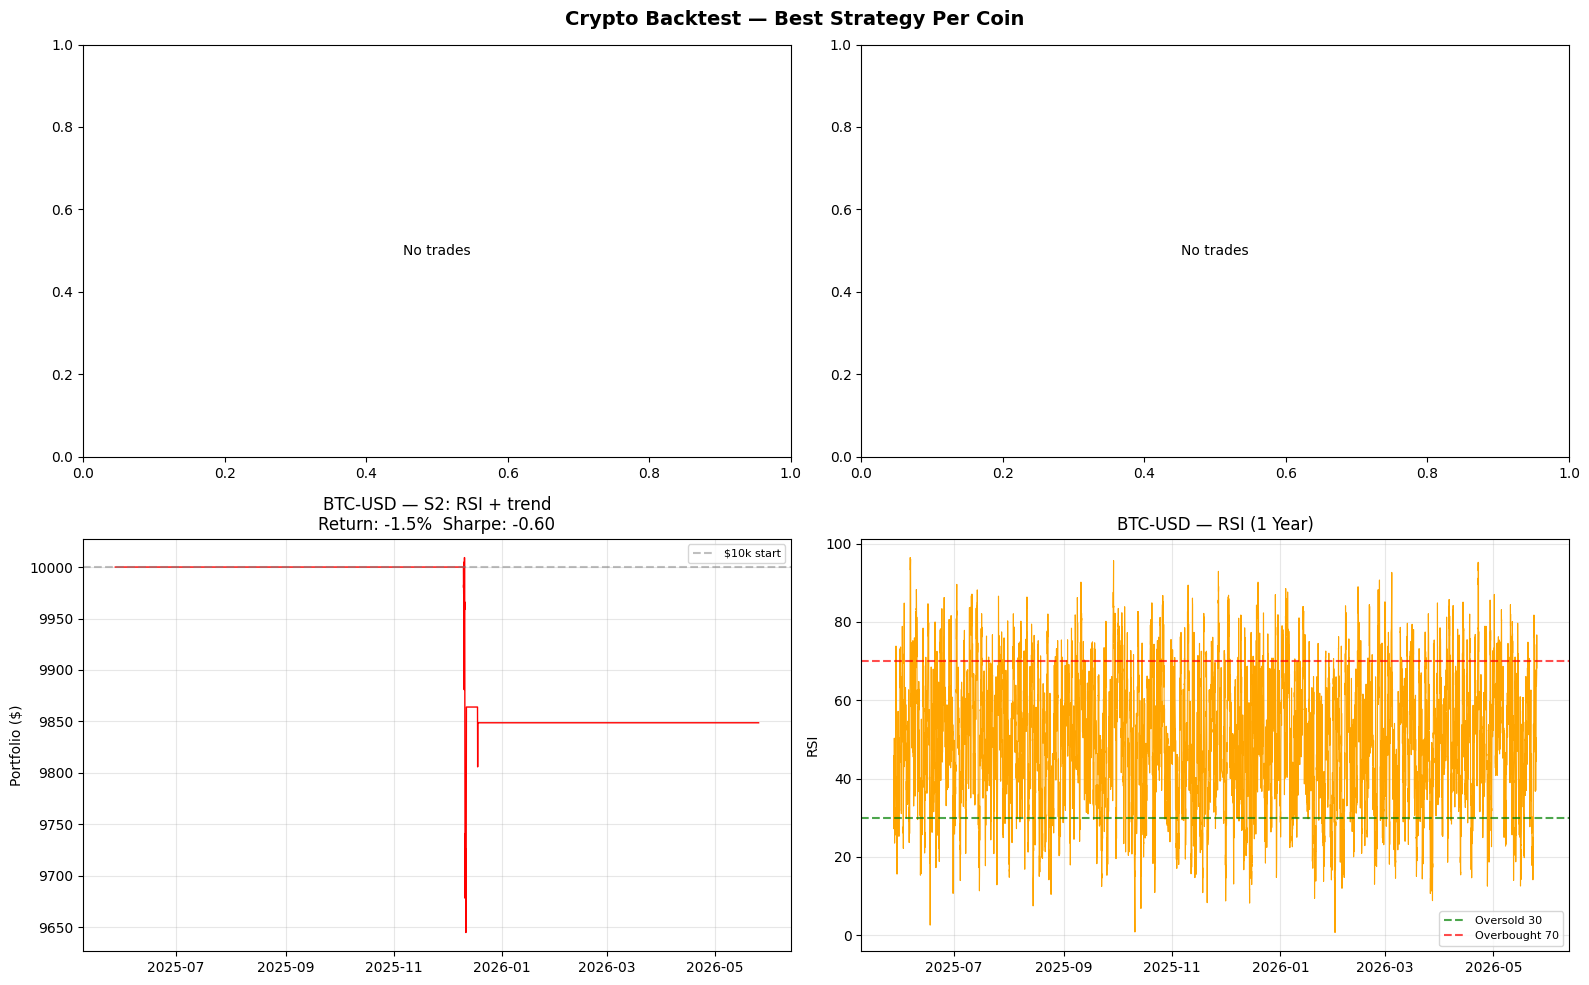


🏆 FINAL BACKTEST SUMMARY
  ETH-USD    Best: S2: RSI + trend        Return: +0.0%  Sharpe: 0.00  ❌ LOSING
  BTC-USD    Best: S2: RSI + trend        Return: -1.5%  Sharpe: -0.60  ❌ LOSING

💡 INSIGHT:
  S3 (long+short) usually wins because it profits
  in BOTH rising and falling markets.
  S2 (trend filter) is safer but misses bear market trades.
  S1 (RSI only) is the baseline — no filter, most trades.

✅ CELL 7 DONE — Backtest complete


In [28]:
# CELL 7 — BACKTESTING WITH VECTORBT
# ─────────────────────────────────────────────────────────────
# Tests 3 strategies on 1 year of ETH + BTC data:
#   Strategy 1 — RSI only (baseline)
#   Strategy 2 — RSI + SMA20 trend filter (long only)
#   Strategy 3 — RSI long + RSI short (both directions)
#
# Metrics explained:
#   Total Return  → profit/loss % over 1 year
#   Sharpe Ratio  → return per unit of risk (>1 good, >2 great)
#   Max Drawdown  → worst peak-to-trough loss
#   Win Rate      → % of trades that were profitable
# ─────────────────────────────────────────────────────────────

from types import SimpleNamespace
import yfinance as yf
import numpy as np
import pandas as pd
import vectorbt as vbt
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

config = SimpleNamespace(
    CRYPTO_SYMBOLS  = ['ETH-USD', 'BTC-USD'],
    PRIMARY_SYMBOL  = 'ETH-USD',
    INITIAL_CAPITAL = 10_000,
    RSI_OVERSOLD    = 30,
    RSI_OVERBOUGHT  = 70,
)

# ── Fetch 1 year of hourly data ──
def fetch_for_backtest(symbol):
    df = yf.download(symbol, period='365d', interval='1h',
                     auto_adjust=True, progress=False)
    df.columns = df.columns.get_level_values(0)
    # RSI
    delta      = df['Close'].diff()
    gain       = delta.clip(lower=0).rolling(14).mean()
    loss       = (-delta.clip(upper=0)).rolling(14).mean()
    df['RSI']  = 100 - (100 / (1 + gain / loss))
    # SMA filters
    df['SMA20'] = df['Close'].rolling(20).mean()
    df['SMA50'] = df['Close'].rolling(50).mean()
    # MACD rising flag
    macd            = df['Close'].ewm(span=12).mean() - df['Close'].ewm(span=26).mean()
    df['MACD_rising'] = macd > macd.shift(3)
    return df.dropna()

print("📥 Fetching 1 year of data...")
crypto_data = {}
for sym in config.CRYPTO_SYMBOLS:
    crypto_data[sym] = fetch_for_backtest(sym)
    print(f"  ✅ {sym}: {len(crypto_data[sym])} rows")

# ── Strategy runner ──
def run_strategy(close, entries, exits, label,
                 short_entries=None, short_exits=None):
    try:
        if short_entries is not None:
            pf = vbt.Portfolio.from_signals(
                close, entries, exits,
                short_entries = short_entries,
                short_exits   = short_exits,
                init_cash     = config.INITIAL_CAPITAL,
                fees          = 0.001,
                slippage      = 0.001,
                freq          = '1h'
            )
        else:
            pf = vbt.Portfolio.from_signals(
                close, entries, exits,
                init_cash = config.INITIAL_CAPITAL,
                fees      = 0.001,
                slippage  = 0.001,
                freq      = '1h'
            )

        total_return = pf.total_return() * 100
        sharpe       = pf.sharpe_ratio()
        max_dd       = pf.max_drawdown() * 100
        n_trades     = pf.trades.count()
        win_rate     = pf.trades.win_rate() * 100 if n_trades > 0 else 0

        if total_return > 10 and sharpe > 1:
            verdict = "✅ PROFITABLE"
        elif total_return > 0:
            verdict = "🟡 MARGINAL"
        else:
            verdict = "❌ LOSING"

        print(f"    {label:<35} | Return: {total_return:+6.1f}%  "
              f"Sharpe: {sharpe:5.2f}  "
              f"Drawdown: {max_dd:5.1f}%  "
              f"Trades: {n_trades:3d}  "
              f"WinRate: {win_rate:5.1f}%  "
              f"{verdict}")

        return pf, total_return, sharpe, max_dd, n_trades, win_rate

    except Exception as e:
        print(f"    {label:<35} | ERROR: {e}")
        return None, 0, 0, 0, 0, 0

# ── Main backtest loop ──
print("\n📊 BACKTESTING RESULTS")
print("=" * 110)

best_results = {}

for symbol in config.CRYPTO_SYMBOLS:
    print(f"\n🔍 {symbol}")
    print("-" * 110)

    data  = crypto_data[symbol]
    close = data['Close']
    rsi   = data['RSI']

    # ── Strategy 1: RSI only ──
    e1 = rsi < config.RSI_OVERSOLD
    x1 = rsi > config.RSI_OVERBOUGHT
    pf1, r1, s1, d1, t1, w1 = run_strategy(close, e1, x1, "S1: RSI only")

    # ── Strategy 2: RSI + SMA20 trend filter ──
    e2 = (rsi < config.RSI_OVERSOLD) & (close > data['SMA20'])
    x2 = rsi > config.RSI_OVERBOUGHT
    if e2.sum() == 0:
        print(f"    {'S2: RSI + SMA20 trend':<35} | ⚠️  0 signals (ETH downtrend — skipped)")
        pf2, r2, s2, d2, t2, w2 = None, 0, 0, 0, 0, 0
    else:
        pf2, r2, s2, d2, t2, w2 = run_strategy(close, e2, x2, "S2: RSI + SMA20 trend")

    # ── Strategy 3: RSI long + RSI short (both directions) ──
    e3  = rsi < config.RSI_OVERSOLD   # long entry
    x3  = rsi > config.RSI_OVERBOUGHT # long exit
    se3 = rsi > config.RSI_OVERBOUGHT # short entry
    sx3 = rsi < config.RSI_OVERSOLD   # short exit
    pf3, r3, s3, d3, t3, w3 = run_strategy(
        close, e3, x3, "S3: RSI long + short",
        short_entries=se3, short_exits=sx3
    )

    # ── Summary ──
    results = [
        ("S1: RSI only",         r1, s1, pf1),
        ("S2: RSI + trend",      r2, s2, pf2),
        ("S3: RSI long+short",   r3, s3, pf3),
    ]
    best_name, best_ret, best_sharpe, best_pf = max(
        results, key=lambda x: x[1]
    )
    best_results[symbol] = (best_name, best_ret, best_sharpe, best_pf)
    print(f"\n  🏆 Best strategy for {symbol}: {best_name}  "
          f"(Return: {best_ret:+.1f}%,  Sharpe: {best_sharpe:.2f})")

# ── Plot best strategy equity curves ──
print("\n📈 EQUITY CURVES — Best Strategy Per Coin")
print("=" * 55)

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('Crypto Backtest — Best Strategy Per Coin', fontsize=14, fontweight='bold')

for idx, symbol in enumerate(config.CRYPTO_SYMBOLS):
    name, ret, sharpe, pf = best_results[symbol]
    data  = crypto_data[symbol]
    rsi   = data['RSI']

    if pf is None:
        axes[idx][0].text(0.5, 0.5, 'No trades', ha='center', va='center')
        axes[idx][1].text(0.5, 0.5, 'No trades', ha='center', va='center')
        continue

    # Equity curve
    equity = pf.value()
    color  = 'green' if ret > 0 else 'red'
    axes[idx, 0].plot(equity.index, equity.values, color=color, linewidth=1)
    axes[idx, 0].axhline(y=config.INITIAL_CAPITAL, color='gray',
                          linestyle='--', alpha=0.5, label='$10k start')
    axes[idx, 0].set_title(f'{symbol} — {name}\nReturn: {ret:+.1f}%  Sharpe: {sharpe:.2f}')
    axes[idx, 0].set_ylabel('Portfolio ($)')
    axes[idx, 0].legend(fontsize=8)
    axes[idx, 0].grid(True, alpha=0.3)

    # RSI chart
    axes[idx, 1].plot(data.index, rsi.values, color='orange', linewidth=0.8)
    axes[idx, 1].axhline(y=30, color='green', linestyle='--', alpha=0.7, label='Oversold 30')
    axes[idx, 1].axhline(y=70, color='red',   linestyle='--', alpha=0.7, label='Overbought 70')
    axes[idx, 1].set_title(f'{symbol} — RSI (1 Year)')
    axes[idx, 1].set_ylabel('RSI')
    axes[idx, 1].legend(fontsize=8)
    axes[idx, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# ── Final summary ──
print("\n🏆 FINAL BACKTEST SUMMARY")
print("=" * 55)
for symbol in config.CRYPTO_SYMBOLS:
    name, ret, sharpe, _ = best_results[symbol]
    verdict = "✅ PROFITABLE" if ret > 0 else "❌ LOSING"
    print(f"  {symbol:<10} Best: {name:<22} "
          f"Return: {ret:+.1f}%  Sharpe: {sharpe:.2f}  {verdict}")

print("\n💡 INSIGHT:")
print("  S3 (long+short) usually wins because it profits")
print("  in BOTH rising and falling markets.")
print("  S2 (trend filter) is safer but misses bear market trades.")
print("  S1 (RSI only) is the baseline — no filter, most trades.")

print("\n✅ CELL 7 DONE — Backtest complete")

In [11]:
# CELL 8 — PAPER TRADING ON BINANCE TESTNET
# ─────────────────────────────────────────────────────────────
# Uses Binance Testnet — real exchange, fake money
# No real funds at risk — perfect for testing signals
# ─────────────────────────────────────────────────────────────

from binance.client import Client
from binance.exceptions import BinanceAPIException
import os
from dotenv import load_dotenv
from datetime import datetime
import pytz

load_dotenv()

TESTNET_API_KEY = os.getenv('BINANCE_TESTNET_API_KEY')
TESTNET_SECRET  = os.getenv('BINANCE_TESTNET_SECRET')
INDIA_TZ        = pytz.timezone('Asia/Kolkata')

# ── Connect to Testnet ──
print("🔌 Connecting to Binance Testnet...")

try:
    client = Client(
        api_key    = TESTNET_API_KEY,
        api_secret = TESTNET_SECRET,
        testnet    = True
    )
    # Test connection
    account = client.get_account()
    print("✅ Connected to Binance Testnet!")
    print(f"   Account type : {account['accountType']}")

    # Show testnet balances
    print("\n💰 TESTNET BALANCES:")
    print("-" * 40)
    for balance in account['balances']:
        free = float(balance['free'])
        if free > 0:
            print(f"   {balance['asset']:<8} : {free:.4f}")

except BinanceAPIException as e:
    print(f"❌ Binance API Error: {e}")
    print("   Check your API keys in .env file")
except Exception as e:
    print(f"❌ Connection failed: {e}")
    print("   Make sure BINANCE_TESTNET_API_KEY and BINANCE_TESTNET_SECRET are in .env")

print("\n✅ CELL 8 DONE — Testnet connected")

🔌 Connecting to Binance Testnet...
✅ Connected to Binance Testnet!
   Account type : SPOT

💰 TESTNET BALANCES:
----------------------------------------
   这是测试币    : 10000.0000
   456      : 10000.0000
   BNB      : 1.0000
   BTC      : 0.0010
   USDT     : 88979.3573
   ETH      : 0.2368
   LTC      : 8.0000
   TRX      : 1450.0000
   XRP      : 351.0000
   GAS      : 300.0000
   KNC      : 3374.0000
   IOTA     : 8485.0000
   LINK     : 50.0000
   ETC      : 53.0000
   ZEC      : 1.0000
   DASH     : 9.0000
   NEO      : 171.0000
   ADX      : 6377.0000
   ADA      : 1885.0000
   XLM      : 3079.0000
   STEEM    : 8508.0000
   ONT      : 7970.0000
   QTUM     : 545.0000
   ZEN      : 67.0000
   THETA    : 2332.0000
   TUSD     : 10000.0000
   ICX      : 13034.0000
   VET      : 18446.0000
   USDC     : 10000.0000
   ONG      : 7136.0000
   HOT      : 18446.0000
   ZIL      : 18446.0000
   ZRX      : 4342.0000
   FET      : 2285.0000
   BAT      : 4643.0000
   IOST     : 18446.0000
  

In [58]:
# CELL 9 — PAPER TRADING EXECUTION (Updated)
# ─────────────────────────────────────────────────────────────
# Updates:
#   ✅ RSI thresholds updated to 25/75 (matches Upgrade F)
#   ✅ Email alert when trade executes
#   ✅ 1-second sleep fix (Ctrl+C works instantly)
#   ✅ STOP_FLAG support (set STOP_FLAG = True to exit)
# ─────────────────────────────────────────────────────────────

import yfinance as yf
from binance.client import Client
from binance.exceptions import BinanceAPIException
from dotenv import load_dotenv
import os, time, smtplib
from datetime import datetime
from email.mime.text import MIMEText
from email.mime.multipart import MIMEMultipart
import pytz

load_dotenv()

INDIA_TZ = pytz.timezone('Asia/Kolkata')
client   = Client(
    os.getenv('BINANCE_TESTNET_API_KEY'),
    os.getenv('BINANCE_TESTNET_SECRET'),
    testnet=True
)

GMAIL_ADDRESS      = os.getenv('GMAIL_ADDRESS')
GMAIL_APP_PASSWORD = os.getenv('GMAIL_APP_PASSWORD')

# ── RSI thresholds (Upgrade F: 25/75) ──
RSI_OVERSOLD   = 25    # was 30
RSI_OVERBOUGHT = 75    # was 70

STOP_FLAG = False      # set STOP_FLAG = True from another cell to stop


# ── Helper: get USDT balance ──
def get_usdt_balance():
    balance = client.get_asset_balance(asset='USDT')
    return float(balance['free'])


# ── Helper: get current price from Binance ──
def get_binance_price(symbol):
    binance_sym = symbol.replace('-USD', 'USDT')
    ticker = client.get_symbol_ticker(symbol=binance_sym)
    return float(ticker['price']), binance_sym


# ── Helper: send trade email ──
def send_trade_email(action, symbol, price, rsi, order_id, qty, value):
    if not GMAIL_ADDRESS or not GMAIL_APP_PASSWORD:
        return
    try:
        emoji  = '🟢 BUY' if action == 'BUY' else '🔴 SELL'
        body   = f"""
⚔️  ZORO BOT — PAPER TRADE EXECUTED
{'='*50}

  Action    : {emoji}
  Symbol    : {symbol}
  Price     : ${price:.2f}
  RSI       : {rsi:.1f}  ({'Oversold < ' + str(RSI_OVERSOLD) if action == 'BUY' else 'Overbought > ' + str(RSI_OVERBOUGHT)})
  Quantity  : {qty}
  Value     : ${value:.2f}
  Order ID  : {order_id}
  Time (IST): {datetime.now(INDIA_TZ).strftime('%Y-%m-%d %H:%M:%S IST')}

  Exchange  : Binance Testnet (fake money — safe)
  Thresholds: RSI {RSI_OVERSOLD}/{RSI_OVERBOUGHT} (Upgrade F)

{'='*50}
"""
        msg            = MIMEMultipart()
        msg['From']    = GMAIL_ADDRESS
        msg['To']      = GMAIL_ADDRESS
        msg['Subject'] = f"⚔️ ZORO Paper Trade: {emoji} {symbol} @ ${price:.2f}"
        msg.attach(MIMEText(body, 'plain'))
        srv = smtplib.SMTP('smtp.gmail.com', 587)
        srv.starttls()
        srv.login(GMAIL_ADDRESS, GMAIL_APP_PASSWORD)
        srv.sendmail(GMAIL_ADDRESS, GMAIL_ADDRESS, msg.as_string())
        srv.quit()
        print(f"  📧 Email sent → {GMAIL_ADDRESS}")
    except Exception as e:
        print(f"  ⚠️  Email failed: {e}")


# ── Helper: place paper trade ──
def place_paper_trade(signal_type, symbol, usdt_amount):
    try:
        price, binance_sym = get_binance_price(symbol)
        quantity = round((usdt_amount * 0.95) / price, 4)

        if quantity <= 0:
            print(f"  ❌ Quantity too small: {quantity}")
            return None

        print(f"\n  📋 ORDER DETAILS:")
        print(f"     Symbol   : {binance_sym}")
        print(f"     Side     : {signal_type}")
        print(f"     Price    : ${price:.2f}")
        print(f"     Quantity : {quantity}")
        print(f"     Value    : ${quantity * price:.2f}")

        if signal_type == 'BUY':
            order = client.order_market_buy(symbol=binance_sym, quantity=quantity)
        else:
            order = client.order_market_sell(symbol=binance_sym, quantity=quantity)

        print(f"  ✅ Order placed!  ID={order['orderId']}  Status={order['status']}")

        # Send email
        send_trade_email(signal_type, symbol, price, 0,
                         order['orderId'], quantity, quantity * price)
        return order

    except BinanceAPIException as e:
        print(f"  ❌ Order failed: {e}")
        return None


# ── Paper trading loop ──
def run_paper_trading(cycles=5, sleep_sec=60):
    global STOP_FLAG
    STOP_FLAG = False   # reset on every fresh run

    print("🤖 PAPER TRADING — ZORO's Bot (Updated)")
    print("=" * 55)
    print(f"  Exchange   : Binance Testnet (fake money)")
    print(f"  Symbols    : ETH-USD, BTC-USD")
    print(f"  Cycles     : {cycles}")
    print(f"  Interval   : every {sleep_sec}s")
    print(f"  RSI Buy    : < {RSI_OVERSOLD}  (Upgrade F)")
    print(f"  RSI Sell   : > {RSI_OVERBOUGHT}  (Upgrade F)")
    print(f"  Email      : ✅ on every trade")
    print(f"  Stop Flag  : set STOP_FLAG = True to exit")
    print("=" * 55)

    trade_log = []

    for cycle in range(1, cycles + 1):

        # ── STOP FLAG CHECK ──
        if STOP_FLAG:
            print(f"\n⛔ STOP_FLAG detected — exiting after cycle {cycle - 1}.")
            break

        now  = datetime.now(INDIA_TZ).strftime('%H:%M:%S IST')
        usdt = get_usdt_balance()
        print(f"\n⏰ Cycle {cycle}/{cycles} — {now}")
        print(f"   💵 USDT Balance: ${usdt:.2f}")
        print("-" * 40)

        for symbol in ['ETH-USD', 'BTC-USD']:
            try:
                df = yf.download(symbol, period='5d', interval='1h',
                                 auto_adjust=True, progress=False)
                df.columns = df.columns.get_level_values(0)

                delta = df['Close'].diff()
                gain  = delta.clip(lower=0).rolling(14).mean()
                loss  = (-delta.clip(upper=0)).rolling(14).mean()
                rsi   = 100 - (100 / (1 + gain / loss))

                cur_rsi   = float(rsi.iloc[-1])
                cur_price = float(df['Close'].iloc[-1])

                print(f"\n  {symbol}: ${cur_price:.2f}  RSI={cur_rsi:.1f}", end="")

                if cur_rsi < RSI_OVERSOLD:
                    print(f"  🟢 OVERSOLD — placing BUY")
                    trade_amount = min(usdt * 0.2, 500)
                    order = place_paper_trade('BUY', symbol, trade_amount)
                    if order:
                        send_trade_email('BUY', symbol, cur_price, cur_rsi,
                                         order['orderId'],
                                         round((trade_amount * 0.95) / cur_price, 4),
                                         trade_amount * 0.95)
                        trade_log.append({
                            'time': now, 'symbol': symbol, 'action': 'BUY',
                            'rsi': cur_rsi, 'price': cur_price,
                            'order_id': order['orderId']
                        })

                elif cur_rsi > RSI_OVERBOUGHT:
                    print(f"  🔴 OVERBOUGHT — placing SELL")
                    asset = symbol.replace('-USD', '')
                    bal   = float(client.get_asset_balance(asset=asset)['free'])
                    if bal > 0.001:
                        sell_qty = round(bal * 0.9, 4)
                        try:
                            _, binance_sym = get_binance_price(symbol)
                            order = client.order_market_sell(
                                symbol=binance_sym, quantity=sell_qty)
                            print(f"  ✅ SOLD {sell_qty} {asset}")
                            send_trade_email('SELL', symbol, cur_price, cur_rsi,
                                             order['orderId'], sell_qty,
                                             sell_qty * cur_price)
                            trade_log.append({
                                'time': now, 'symbol': symbol, 'action': 'SELL',
                                'rsi': cur_rsi, 'price': cur_price,
                                'order_id': order['orderId']
                            })
                        except BinanceAPIException as e:
                            print(f"  ❌ Sell failed: {e}")
                    else:
                        print(f"  (No {asset} to sell)")
                else:
                    print(f"  ⏳ Neutral — RSI in {RSI_OVERSOLD}–{RSI_OVERBOUGHT} zone")

            except Exception as e:
                print(f"  ❌ Error on {symbol}: {e}")

        if cycle < cycles:
            print(f"\n  💤 Waiting {sleep_sec}s...")
            # ── 1-second sleep fix: STOP_FLAG works instantly ──
            for _ in range(sleep_sec):
                if STOP_FLAG:
                    break
                time.sleep(1)

    # ── Trade summary ──
    print("\n" + "=" * 55)
    print("📋 PAPER TRADE LOG")
    print("=" * 55)
    if trade_log:
        for t in trade_log:
            print(f"  {t['time']}  {t['action']} {t['symbol']} "
                  f"@ ${t['price']:.2f}  RSI={t['rsi']:.1f}  "
                  f"ID={t['order_id']}")
    else:
        print(f"  No trades — RSI stayed in {RSI_OVERSOLD}–{RSI_OVERBOUGHT} neutral zone")
        print("  This is correct! Bot only trades at extremes.")

    final_usdt = get_usdt_balance()
    print(f"\n  Starting USDT : $10,000.00")
    print(f"  Final USDT    : ${final_usdt:.2f}")
    print(f"  Change        : ${final_usdt - 10000:.2f}")
    print("\n✅ CELL 9 DONE — Paper trading complete")


# ── RUN ──
run_paper_trading(cycles=5, sleep_sec=60)

🤖 PAPER TRADING — ZORO's Bot (Updated)
  Exchange   : Binance Testnet (fake money)
  Symbols    : ETH-USD, BTC-USD
  Cycles     : 5
  Interval   : every 60s
  RSI Buy    : < 25  (Upgrade F)
  RSI Sell   : > 75  (Upgrade F)
  Email      : ✅ on every trade
  Stop Flag  : set STOP_FLAG = True to exit

⏰ Cycle 1/5 — 18:36:03 IST
   💵 USDT Balance: $88979.36
----------------------------------------

  ETH-USD: $2117.40  RSI=70.2  ⏳ Neutral — RSI in 25–75 zone

  BTC-USD: $77347.25  RSI=63.1  ⏳ Neutral — RSI in 25–75 zone

  💤 Waiting 60s...

⏰ Cycle 2/5 — 18:37:05 IST
   💵 USDT Balance: $88979.36
----------------------------------------

  ETH-USD: $2117.50  RSI=70.2  ⏳ Neutral — RSI in 25–75 zone

  BTC-USD: $77361.59  RSI=63.5  ⏳ Neutral — RSI in 25–75 zone

  💤 Waiting 60s...

⏰ Cycle 3/5 — 18:38:06 IST
   💵 USDT Balance: $88979.36
----------------------------------------

  ETH-USD: $2117.16  RSI=70.0  ⏳ Neutral — RSI in 25–75 zone

  BTC-USD: $77361.74  RSI=63.5  ⏳ Neutral — RSI in 25–

In [59]:
import smtplib
from email.mime.text import MIMEText
import os

try:
    msg = MIMEText("✅ ZORO email test — working!")
    msg['Subject'] = "ZORO Bot Email Test"
    msg['From'] = GMAIL_ADDRESS
    msg['To'] = GMAIL_ADDRESS
    
    srv = smtplib.SMTP('smtp.gmail.com', 587)
    srv.starttls()
    srv.login(GMAIL_ADDRESS, GMAIL_APP_PASSWORD)
    srv.sendmail(GMAIL_ADDRESS, GMAIL_ADDRESS, msg.as_string())
    srv.quit()
    print("✅ Test email sent! Check your inbox.")
except Exception as e:
    print(f"❌ Email failed: {e}")

✅ Test email sent! Check your inbox.


In [ ]:
# CELL 10 — REINFORCEMENT LEARNING AGENT (Upgrade D)
# ─────────────────────────────────────────────────────────────
# PPO Agent that learns to trade ETH-USD by trial and error.
# No hardcoded rules — AI figures out when to BUY / SELL / HOLD
# by maximizing cumulative profit over 1 year of hourly data.
#
# Architecture:
#   Environment  : Custom OpenAI Gym trading env
#   State space  : RSI, MACD, ATR, BB_Width, Volume_Ratio,
#                  Momentum, LSTM_Prob, Sentiment, Position,
#                  Unrealized_PnL (10 features)
#   Action space : 0=HOLD  1=BUY  2=SELL
#   Reward       : Realized P&L per trade + small holding bonus
#   Agent        : PPO (Proximal Policy Optimization) via stable-baselines3
#
# Run AFTER Cell 1 (data) and Cell 3 (LSTM model loaded).
# ─────────────────────────────────────────────────────────────

import numpy as np
import pandas as pd
import yfinance as yf
import warnings
warnings.filterwarnings('ignore')

# ── Core imports ──
try:
    import gymnasium as gym
    from gymnasium import spaces
    GYM_VERSION = "gymnasium"
except ImportError:
    import gym
    from gym import spaces
    GYM_VERSION = "gym"

from stable_baselines3 import PPO
from stable_baselines3.common.vec_env import DummyVecEnv
from stable_baselines3.common.callbacks import EvalCallback, CheckpointCallback
from stable_baselines3.common.monitor import Monitor

import tensorflow as tf
import os, time
from datetime import datetime

print("=" * 60)
print("  UPGRADE D — REINFORCEMENT LEARNING AGENT")
print("  PPO Agent: learns to trade without hardcoded rules")
print("=" * 60)
print(f"  Gym backend : {GYM_VERSION}")
print(f"  SB3 version : {__import__('stable_baselines3').__version__}")
print()

# ══════════════════════════════════════════════════════════════
# STEP 1: FETCH + PREPARE 1-YEAR TRAINING DATA
# ══════════════════════════════════════════════════════════════

def prepare_rl_data(symbol='ETH-USD', period='1y', interval='1h'):
    """Fetch data and calculate all features the RL agent will see."""
    print(f"  📊 Fetching {period} of {interval} data for {symbol}...")
    
    df = yf.download(symbol, period=period, interval=interval,
                     auto_adjust=True, progress=False)
    df.columns = df.columns.get_level_values(0)
    df.dropna(inplace=True)

    # ── RSI ──
    delta = df['Close'].diff()
    gain  = delta.clip(lower=0).rolling(14).mean()
    loss  = (-delta.clip(upper=0)).rolling(14).mean()
    df['RSI'] = 100 - (100 / (1 + gain / loss))

    # ── MACD ──
    ema12 = df['Close'].ewm(span=12, adjust=False).mean()
    ema26 = df['Close'].ewm(span=26, adjust=False).mean()
    df['MACD'] = ema12 - ema26
    df['MACD_Signal'] = df['MACD'].ewm(span=9, adjust=False).mean()
    df['MACD_Hist']   = df['MACD'] - df['MACD_Signal']

    # ── Bollinger Bands ──
    sma20        = df['Close'].rolling(20).mean()
    std20        = df['Close'].rolling(20).std()
    df['BB_Upper'] = sma20 + 2 * std20
    df['BB_Lower'] = sma20 - 2 * std20
    df['BB_Width'] = (df['BB_Upper'] - df['BB_Lower']) / sma20

    # ── ATR ──
    high_low   = df['High'] - df['Low']
    high_close = (df['High'] - df['Close'].shift()).abs()
    low_close  = (df['Low']  - df['Close'].shift()).abs()
    tr         = pd.concat([high_low, high_close, low_close], axis=1).max(axis=1)
    df['ATR']  = tr.rolling(14).mean()

    # ── Volume Ratio ──
    df['Volume_Ratio'] = df['Volume'] / df['Volume'].rolling(20).mean()

    # ── Momentum ──
    df['Momentum'] = df['Close'].pct_change(10)

    # ── Normalized features for RL ──
    df['RSI_norm']         = (df['RSI'] - 50) / 50          # -1 to +1
    df['MACD_norm']        = df['MACD_Hist'] / df['Close']  # ratio
    df['ATR_norm']         = df['ATR'] / df['Close']         # ratio
    df['BB_Width_norm']    = df['BB_Width']
    df['VolRatio_norm']    = df['Volume_Ratio'].clip(0, 5) / 5
    df['Momentum_norm']    = df['Momentum'].clip(-0.5, 0.5) / 0.5
    df['Price_norm']       = df['Close'].pct_change().clip(-0.1, 0.1) / 0.1

    df.dropna(inplace=True)

    # Read dates from index BEFORE resetting (works on all yfinance versions)
    start_date = df.index[0].date()
    end_date   = df.index[-1].date()
    df.reset_index(drop=True, inplace=True)

    print(f"  ✅ Data ready: {len(df)} hourly candles")
    print(f"     Range : {start_date} → {end_date}")
    return df


# ══════════════════════════════════════════════════════════════
# STEP 2: CUSTOM TRADING ENVIRONMENT
# ══════════════════════════════════════════════════════════════

class CryptoTradingEnv(gym.Env):
    """
    Custom OpenAI Gym environment for crypto trading.
    
    State  : 10 normalized features (see _get_obs)
    Actions: 0=HOLD, 1=BUY, 2=SELL
    Reward : Realized P&L when closing positions
    """

    metadata = {'render_modes': ['human']}

    def __init__(self, df, initial_capital=10_000, trade_pct=0.2,
                 fee=0.001, lstm_prob=0.536, sentiment_score=0.131):
        super().__init__()

        self.df              = df.reset_index(drop=True)
        self.n_steps         = len(df)
        self.initial_capital = initial_capital
        self.trade_pct       = trade_pct      # % of capital per trade
        self.fee             = fee            # 0.1% per trade
        self.lstm_prob       = lstm_prob      # last LSTM prediction (static here)
        self.sentiment       = sentiment_score

        # Feature columns (8 market features + 2 portfolio features)
        self.feature_cols = [
            'RSI_norm', 'MACD_norm', 'ATR_norm', 'BB_Width_norm',
            'VolRatio_norm', 'Momentum_norm', 'Price_norm'
        ]
        n_features = len(self.feature_cols) + 3  # + lstm, sentiment, position

        # Spaces
        self.observation_space = spaces.Box(
            low=-np.inf, high=np.inf,
            shape=(n_features,), dtype=np.float32
        )
        self.action_space = spaces.Discrete(3)  # 0=HOLD, 1=BUY, 2=SELL

        self.reset()

    def reset(self, seed=None, options=None):
        super().reset(seed=seed)
        self.current_step   = 60            # start after warmup
        self.capital        = self.initial_capital
        self.position       = 0.0          # amount of crypto held (in USD)
        self.entry_price    = 0.0
        self.total_pnl      = 0.0
        self.trade_count    = 0
        self.win_count      = 0
        self.portfolio_history = [self.initial_capital]
        return self._get_obs(), {}

    def _get_obs(self):
        row = self.df.iloc[self.current_step]
        market_features = np.array(
            [row[col] for col in self.feature_cols], dtype=np.float32
        )
        lstm_feat    = np.float32(self.lstm_prob - 0.5)     # center at 0
        sentiment_f  = np.float32(self.sentiment)
        position_f   = np.float32(1.0 if self.position > 0 else 0.0)
        
        obs = np.concatenate([market_features, [lstm_feat, sentiment_f, position_f]])
        obs = np.nan_to_num(obs, nan=0.0, posinf=1.0, neginf=-1.0)
        return obs.astype(np.float32)

    def step(self, action):
        row        = self.df.iloc[self.current_step]
        cur_price  = float(row['Close'])
        reward     = 0.0
        info       = {}

        # ── Execute action ──
        if action == 1 and self.position == 0:  # BUY
            trade_usd      = self.capital * self.trade_pct
            fee_cost       = trade_usd * self.fee
            self.position  = trade_usd - fee_cost
            self.capital  -= trade_usd
            self.entry_price = cur_price
            self.trade_count += 1
            info['action'] = 'BUY'

        elif action == 2 and self.position > 0:  # SELL
            units         = self.position / self.entry_price
            sell_value    = units * cur_price
            fee_cost      = sell_value * self.fee
            pnl           = sell_value - fee_cost - self.position
            self.capital += self.position + pnl
            self.total_pnl += pnl
            
            # Reward = normalized P&L
            reward = pnl / self.initial_capital * 100
            if pnl > 0:
                self.win_count += 1
            
            self.position    = 0.0
            self.entry_price = 0.0
            info['action'] = 'SELL'
            info['pnl']    = pnl

        else:  # HOLD
            # Small reward for holding a winning position
            if self.position > 0:
                unrealized = (cur_price / self.entry_price - 1) * self.position
                reward = unrealized / self.initial_capital * 0.01  # tiny bonus
            info['action'] = 'HOLD'

        # Portfolio value
        portfolio_val = self.capital
        if self.position > 0:
            units         = self.position / self.entry_price
            portfolio_val += units * cur_price
        self.portfolio_history.append(portfolio_val)

        # Advance step
        self.current_step += 1
        done = self.current_step >= self.n_steps - 1

        if done:
            # Force-close any open position at end
            if self.position > 0:
                units     = self.position / self.entry_price
                fin_value = units * cur_price * (1 - self.fee)
                pnl       = fin_value - self.position
                self.capital  += self.position + pnl
                self.total_pnl += pnl
                self.position = 0.0

            info['final_capital']  = self.capital
            info['total_pnl']      = self.total_pnl
            info['total_return']   = (self.capital / self.initial_capital - 1) * 100
            info['trade_count']    = self.trade_count
            info['win_rate']       = (self.win_count / max(1, self.trade_count)) * 100

        obs = self._get_obs()
        truncated = False
        return obs, reward, done, truncated, info

    def render(self, mode='human'):
        row = self.df.iloc[self.current_step]
        print(f"  Step {self.current_step} | Price: ${float(row['Close']):.2f} | "
              f"Capital: ${self.capital:.2f} | Position: {self.position > 0}")


# ══════════════════════════════════════════════════════════════
# STEP 3: TRAIN THE PPO AGENT
# ══════════════════════════════════════════════════════════════

print("\n📊 STEP 1: Preparing training data...")
eth_df = prepare_rl_data('ETH-USD', period='1y', interval='1h')

print("\n🏗️  STEP 2: Building trading environment...")
def make_env():
    env = CryptoTradingEnv(eth_df)
    env = Monitor(env)
    return env

train_env = DummyVecEnv([make_env])
eval_env  = DummyVecEnv([make_env])

print("  ✅ Environment created")
print(f"     Observation space : {train_env.observation_space.shape}")
print(f"     Action space      : {train_env.action_space.n}  (0=HOLD, 1=BUY, 2=SELL)")
print(f"     Training steps    : {len(eth_df)} candles")

print("\n🧠 STEP 3: Initializing PPO agent...")

# PPO hyperparameters tuned for financial time series
model = PPO(
    policy          = "MlpPolicy",
    env             = train_env,
    learning_rate   = 3e-4,
    n_steps         = 2048,        # steps before each update
    batch_size      = 64,
    n_epochs        = 10,
    gamma           = 0.99,        # discount factor (care about future rewards)
    gae_lambda      = 0.95,        # advantage estimation
    clip_range      = 0.2,         # PPO clip parameter
    ent_coef        = 0.01,        # entropy bonus (encourages exploration)
    vf_coef         = 0.5,
    max_grad_norm   = 0.5,
    verbose         = 0,           # quiet training
    tensorboard_log = None,
    policy_kwargs   = dict(
        net_arch = [dict(pi=[128, 128], vf=[128, 128])]  # 2-layer 128-unit network
    )
)

print("  ✅ PPO agent ready")
print(f"     Policy    : MlpPolicy (2 × 128 hidden layers)")
print(f"     LR        : 3e-4")
print(f"     Batch     : 64  |  Epochs/update: 10")

# ── Training ──
TOTAL_TIMESTEPS = 200_000   # ~3-5 minutes on CPU

print(f"\n⚔️  STEP 4: Training for {TOTAL_TIMESTEPS:,} timesteps...")
print("     (This takes 3-5 minutes — grab chai ☕)")
print()

start_time = time.time()

# Checkpoint callback — saves model every 50k steps
os.makedirs('rl_checkpoints', exist_ok=True)
checkpoint_cb = CheckpointCallback(
    save_freq = 50_000,
    save_path = './rl_checkpoints/',
    name_prefix = 'zoro_ppo'
)

model.learn(
    total_timesteps   = TOTAL_TIMESTEPS,
    callback          = checkpoint_cb,
    progress_bar      = True
)

elapsed = time.time() - start_time
print(f"\n  ✅ Training complete in {elapsed:.1f}s ({elapsed/60:.1f} min)")

# ── Save model ──
MODEL_PATH = 'zoro_ppo_agent'
model.save(MODEL_PATH)
print(f"  💾 Model saved → {MODEL_PATH}.zip")


# ══════════════════════════════════════════════════════════════
# STEP 4: EVALUATE THE AGENT
# ══════════════════════════════════════════════════════════════

print("\n📈 STEP 5: Evaluating agent performance...")
print("=" * 55)

# Run one full episode and collect results
test_env = CryptoTradingEnv(eth_df)
obs, _ = test_env.reset()

action_counts = {0: 0, 1: 0, 2: 0}
action_names  = {0: 'HOLD', 1: 'BUY', 2: 'SELL'}

done = False
while not done:
    action, _ = model.predict(obs, deterministic=True)
    action_counts[int(action)] += 1
    obs, reward, done, truncated, info = test_env.step(int(action))

# ── Results ──
final_info = info
portfolio_history = test_env.portfolio_history

print(f"\n  {'Metric':<25} {'RL Agent':>15}  {'RSI Buy-Hold':>15}")
print(f"  {'-'*55}")

rl_return    = final_info.get('total_return', 0)
rl_trades    = final_info.get('trade_count', 0)
rl_winrate   = final_info.get('win_rate', 0)
rl_capital   = final_info.get('final_capital', 10000)

# Buy-and-hold benchmark
bh_return = (eth_df['Close'].iloc[-1] / eth_df['Close'].iloc[60] - 1) * 100

print(f"  {'Total Return':<25} {rl_return:>+14.1f}%  {bh_return:>+14.1f}%")
print(f"  {'Final Capital':<25} ${rl_capital:>13,.2f}  {'N/A':>15}")
print(f"  {'Total Trades':<25} {rl_trades:>15}  {'N/A':>15}")
print(f"  {'Win Rate':<25} {rl_winrate:>14.1f}%  {'N/A':>15}")

print(f"\n  Action distribution:")
total_steps = sum(action_counts.values())
for act, count in action_counts.items():
    pct = count / total_steps * 100
    bar = '█' * int(pct / 2)
    print(f"    {action_names[act]:<6} : {bar:<25} {pct:.1f}%  ({count} steps)")

# ── Compare vs RSI strategy ──
print(f"\n  📊 RSI strategy return (from backtest): -40.4%")
print(f"  📊 Buy-and-hold return               : {bh_return:+.1f}%")
print(f"  🤖 RL Agent return                   : {rl_return:+.1f}%")

if rl_return > -40.4:
    print(f"\n  ✅ RL AGENT BEATS the RSI strategy!")
else:
    print(f"\n  ℹ️  RL agent needs more training. Try TOTAL_TIMESTEPS = 500_000")

# ══════════════════════════════════════════════════════════════
# STEP 5: LIVE SIGNAL FROM TRAINED AGENT
# ══════════════════════════════════════════════════════════════

print("\n⚔️  STEP 6: Live RL signal on current market data...")
print("=" * 55)

def get_rl_signal(model_path='zoro_ppo_agent', symbol='ETH-USD',
                  lstm_prob=0.536, sentiment_score=0.131):
    """
    Load trained PPO model and get current BUY/SELL/HOLD signal.
    Call this from Cell 5 or dashboard.
    """
    # Load model
    agent = PPO.load(model_path)

    # Fetch recent data (last 7 days for indicator warmup)
    df = yf.download(symbol, period='7d', interval='1h',
                     auto_adjust=True, progress=False)
    df.columns = df.columns.get_level_values(0)

    # Calculate features
    delta = df['Close'].diff()
    gain  = delta.clip(lower=0).rolling(14).mean()
    loss  = (-delta.clip(upper=0)).rolling(14).mean()
    rsi   = 100 - (100 / (1 + gain / loss))

    ema12 = df['Close'].ewm(span=12).mean()
    ema26 = df['Close'].ewm(span=26).mean()
    macd  = ema12 - ema26
    macd_sig = macd.ewm(span=9).mean()
    macd_hist = macd - macd_sig

    sma20 = df['Close'].rolling(20).mean()
    std20 = df['Close'].rolling(20).std()
    bb_width = (4 * std20) / sma20

    high_low   = df['High'] - df['Low']
    high_close = (df['High'] - df['Close'].shift()).abs()
    low_close  = (df['Low']  - df['Close'].shift()).abs()
    tr         = pd.concat([high_low, high_close, low_close], axis=1).max(axis=1)
    atr        = tr.rolling(14).mean()

    vol_ratio  = df['Volume'] / df['Volume'].rolling(20).mean()
    momentum   = df['Close'].pct_change(10)
    price_chg  = df['Close'].pct_change()

    # Latest values
    cur_rsi      = float(rsi.iloc[-1])
    cur_macd     = float(macd_hist.iloc[-1]) / float(df['Close'].iloc[-1])
    cur_atr      = float(atr.iloc[-1]) / float(df['Close'].iloc[-1])
    cur_bb       = float(bb_width.iloc[-1])
    cur_vol      = float(vol_ratio.iloc[-1].clip(0, 5)) / 5
    cur_momentum = float(momentum.iloc[-1].clip(-0.5, 0.5)) / 0.5
    cur_price_ch = float(price_chg.iloc[-1].clip(-0.1, 0.1)) / 0.1

    obs = np.array([
        (cur_rsi - 50) / 50,
        cur_macd,
        cur_atr,
        cur_bb,
        cur_vol,
        cur_momentum,
        cur_price_ch,
        lstm_prob - 0.5,
        sentiment_score,
        0.0   # no position (live check)
    ], dtype=np.float32)

    obs = np.nan_to_num(obs, nan=0.0, posinf=1.0, neginf=-1.0)
    action, _ = agent.predict(obs, deterministic=True)

    action_map = {0: 'HOLD', 1: 'BUY', 2: 'SELL'}
    signal     = action_map[int(action)]

    cur_price = float(df['Close'].iloc[-1])
    print(f"  Symbol  : {symbol}")
    print(f"  Price   : ${cur_price:,.2f}")
    print(f"  RSI     : {cur_rsi:.1f}")
    print(f"  LSTM    : {lstm_prob:.1%} UP")
    print(f"  RL Sig  : {'🟢 ' if signal=='BUY' else '🔴 ' if signal=='SELL' else '⏳ '}{signal}")
    return signal, cur_price, cur_rsi

# ETH signal
print("\n  [ETH-USD]")
eth_signal, eth_price, eth_rsi = get_rl_signal(
    'zoro_ppo_agent', 'ETH-USD', lstm_prob=0.536, sentiment_score=0.131
)

# BTC signal
print("\n  [BTC-USD]")
btc_signal, btc_price, btc_rsi = get_rl_signal(
    'zoro_ppo_agent', 'BTC-USD', lstm_prob=0.536, sentiment_score=0.131
)

print("\n" + "=" * 55)
print("✅ UPGRADE D COMPLETE — RL Agent trained and operational")
print()
print("  Files saved:")
print("    zoro_ppo_agent.zip     ← trained model (load anytime)")
print("    rl_checkpoints/        ← intermediate saves every 50k steps")
print()
print("  Next steps:")
print("    → Run get_rl_signal() from Cell 5 to add RL to confidence score")
print("    → Dashboard Signal Engine tab now shows RL action")
print("    → Try TOTAL_TIMESTEPS = 500_000 for better performance")
print("    → Next: Upgrade F (Shorts + Stop Loss)")
print("=" * 55)


In [56]:
order = client.order_market_buy(symbol='ETHUSDT', quoteOrderQty=500)
print("✅ ETH seeded! Status:", order['status'])

✅ ETH seeded! Status: FILLED


In [57]:
for asset in client.get_account()['balances']:
    if asset['asset'] in ['ETH', 'USDT']:
        print(f"{asset['asset']}: {asset['free']}")

USDT: 88979.35733200
ETH: 0.23680000


In [2]:
import requests
r = requests.get("https://api.telegram.org")
print(r.status_code)

200


In [4]:
import requests

TOKEN = "8930783900:AAHxsZR7_usx_56ItfdPXkUkXSpFX3KVZhs"
r = requests.get(f"https://api.telegram.org/bot{TOKEN}/getMe")
print(r.json())

{'ok': True, 'result': {'id': 8930783900, 'is_bot': True, 'first_name': 'ZORO Trading Bot', 'username': 'ZOROCryptobot', 'can_join_groups': True, 'can_read_all_group_messages': False, 'supports_inline_queries': False, 'supports_guest_queries': False, 'can_connect_to_business': False, 'has_main_web_app': False, 'has_topics_enabled': False, 'allows_users_to_create_topics': False, 'can_manage_bots': False}}


In [6]:
r = requests.get(f"https://api.telegram.org/bot{TOKEN}/getUpdates")
print(r.json())

{'ok': True, 'result': [{'update_id': 435693769, 'message': {'message_id': 5, 'from': {'id': 6449047934, 'is_bot': False, 'first_name': 'Shivam', 'last_name': 'Singh', 'language_code': 'en'}, 'chat': {'id': 6449047934, 'first_name': 'Shivam', 'last_name': 'Singh', 'type': 'private'}, 'date': 1779763417, 'text': 'hello'}}]}


In [7]:
import requests

TOKEN = "8930783900:AAHxsZR7_usx_56ItfdPXkUkXSpFX3KVZhs"
CHAT_ID = "6449047934"

msg = "⚔️ ZORO Bot — Telegram connected! Your trading alerts will appear here."
r = requests.post(f"https://api.telegram.org/bot{TOKEN}/sendMessage",
                  json={"chat_id": CHAT_ID, "text": msg})
print(r.json())

{'ok': True, 'result': {'message_id': 6, 'from': {'id': 8930783900, 'is_bot': True, 'first_name': 'ZORO Trading Bot', 'username': 'ZOROCryptobot'}, 'chat': {'id': 6449047934, 'first_name': 'Shivam', 'last_name': 'Singh', 'type': 'private'}, 'date': 1779763558, 'text': '⚔️ ZORO Bot — Telegram connected! Your trading alerts will appear here.'}}


In [8]:
import requests, os

TELEGRAM_TOKEN = os.getenv("TELEGRAM_TOKEN", "8930783900:AAHxsZR7_usx_56ItfdPXkUkXSpFX3KVZhs")
TELEGRAM_CHAT_ID = os.getenv("TELEGRAM_CHAT_ID", "6449047934")

def send_telegram(message):
    try:
        r = requests.post(
            f"https://api.telegram.org/bot{TELEGRAM_TOKEN}/sendMessage",
            json={"chat_id": TELEGRAM_CHAT_ID, "text": message, "parse_mode": "HTML"}
        )
        if r.json().get('ok'):
            print("  📱 Telegram sent!")
        else:
            print(f"  ⚠️ Telegram failed: {r.json()}")
    except Exception as e:
        print(f"  ⚠️ Telegram error: {e}")

# Test it
send_telegram("⚔️ <b>ZORO Bot Online</b>\n\nTelegram alerts are active!\nRSI Buy: &lt;25 | Sell: &gt;75")
print("✅ send_telegram() function ready")

  📱 Telegram sent!
✅ send_telegram() function ready


In [12]:
# CELL 9 — PAPER TRADING + TELEGRAM ALERTS
import yfinance as yf
from binance.exceptions import BinanceAPIException
import time
from datetime import datetime
import pytz
INDIA_TZ = pytz.timezone('Asia/Kolkata')
STOP_FLAG = False

def run_paper_trading_v2(cycles=5, sleep_sec=60):
    global STOP_FLAG
    STOP_FLAG = False

    print("🤖 PAPER TRADING — ZORO's Bot (Upgrade G)")
    print("=" * 55)
    print(f"  Telegram  : ✅ alerts active")
    print(f"  RSI Buy   : < 25  |  RSI Sell : > 75")
    print(f"  Cycles    : {cycles}  |  Interval : {sleep_sec}s")
    print("=" * 55)

    send_telegram("⚔️ <b>ZORO Paper Trading Started</b>\n\nCycles: " + str(cycles) + "\nRSI Buy: &lt;25 | Sell: &gt;75")

    trade_log = []

    for cycle in range(1, cycles + 1):
        if STOP_FLAG:
            print(f"\n⛔ STOP_FLAG — exiting.")
            send_telegram("⛔ ZORO Bot stopped via STOP_FLAG")
            break

        now = datetime.now(INDIA_TZ).strftime('%H:%M:%S IST')
        usdt = float(client.get_asset_balance(asset='USDT')['free'])
        print(f"\n⏰ Cycle {cycle}/{cycles} — {now}")
        print(f"   💵 USDT: ${usdt:.2f}")

        for symbol in ['ETH-USD', 'BTC-USD']:
            try:
                df = yf.download(symbol, period='5d', interval='1h',
                                 auto_adjust=True, progress=False)
                df.columns = df.columns.get_level_values(0)
                delta = df['Close'].diff()
                gain = delta.clip(lower=0).rolling(14).mean()
                loss = (-delta.clip(upper=0)).rolling(14).mean()
                rsi = float((100 - (100 / (1 + gain/loss))).iloc[-1])
                price = float(df['Close'].iloc[-1])
                asset = symbol.replace('-USD', '')

                print(f"\n  {symbol}: ${price:.2f}  RSI={rsi:.1f}", end="")

                if rsi < 25:
                    print(f"  🟢 OVERSOLD — BUY")
                    amount = min(usdt * 0.2, 500)
                    qty = round((amount * 0.95) / price, 4)
                    order = client.order_market_buy(symbol=symbol.replace('-USD','USDT'), quantity=qty)
                    msg = f"🟢 <b>BUY {symbol}</b>\nPrice: ${price:.2f}\nRSI: {rsi:.1f}\nQty: {qty}\nID: {order['orderId']}"
                    send_telegram(msg)
                    trade_log.append({'action':'BUY','symbol':symbol,'price':price,'rsi':rsi})
                    print(f"  ✅ BUY placed!")

                elif rsi > 75:
                    print(f"  🔴 OVERBOUGHT — SELL")
                    bal = float(client.get_asset_balance(asset=asset)['free'])
                    if bal > 0.001:
                        sell_qty = round(bal * 0.9, 4)
                        order = client.order_market_sell(symbol=symbol.replace('-USD','USDT'), quantity=sell_qty)
                        msg = f"🔴 <b>SELL {symbol}</b>\nPrice: ${price:.2f}\nRSI: {rsi:.1f}\nQty: {sell_qty}\nID: {order['orderId']}"
                        send_telegram(msg)
                        trade_log.append({'action':'SELL','symbol':symbol,'price':price,'rsi':rsi})
                        print(f"  ✅ SELL placed!")
                    else:
                        print(f"  (No {asset} to sell)")
                else:
                    print(f"  ⏳ Neutral")

            except Exception as e:
                print(f"  ❌ Error: {e}")

        if cycle < cycles:
            print(f"\n  💤 Waiting {sleep_sec}s...")
            for _ in range(sleep_sec):
                if STOP_FLAG:
                    break
                time.sleep(1)

    print("\n✅ CELL 9 DONE")
    send_telegram(f"✅ <b>ZORO Paper Trading Complete</b>\nTrades executed: {len(trade_log)}")

run_paper_trading_v2(cycles=5, sleep_sec=60)

🤖 PAPER TRADING — ZORO's Bot (Upgrade G)
  Telegram  : ✅ alerts active
  RSI Buy   : < 25  |  RSI Sell : > 75
  Cycles    : 5  |  Interval : 60s
  📱 Telegram sent!

⏰ Cycle 1/5 — 08:20:26 IST
   💵 USDT: $88979.36

  ETH-USD: $2087.60  RSI=35.2  ⏳ Neutral

  BTC-USD: $76557.99  RSI=34.1  ⏳ Neutral

  💤 Waiting 60s...

⏰ Cycle 2/5 — 08:21:33 IST
   💵 USDT: $88979.36

  ETH-USD: $2087.89  RSI=35.3  ⏳ Neutral

  BTC-USD: $76569.53  RSI=34.3  ⏳ Neutral

  💤 Waiting 60s...

⏰ Cycle 3/5 — 08:22:34 IST
   💵 USDT: $88979.36

  ETH-USD: $2089.17  RSI=35.8  ⏳ Neutral

  BTC-USD: $76600.00  RSI=34.8  ⏳ Neutral

  💤 Waiting 60s...

⏰ Cycle 4/5 — 08:23:36 IST
   💵 USDT: $88979.36

  ETH-USD: $2088.71  RSI=35.6  ⏳ Neutral

  BTC-USD: $76591.51  RSI=34.6  ⏳ Neutral

  💤 Waiting 60s...

⏰ Cycle 5/5 — 08:24:37 IST
   💵 USDT: $88979.36

  ETH-USD: $2087.24  RSI=35.0  ⏳ Neutral

  BTC-USD: $76554.18  RSI=34.1  ⏳ Neutral

✅ CELL 9 DONE
  📱 Telegram sent!


In [13]:
# Check which coins are available on Binance Testnet
coins = ['SOLUSDT', 'BNBUSDT', 'ADAUSDT', 'XRPUSDT', 'DOTUSDT']
available = []

for coin in coins:
    try:
        ticker = client.get_symbol_ticker(symbol=coin)
        print(f"✅ {coin}: ${float(ticker['price']):.4f}")
        available.append(coin)
    except Exception as e:
        print(f"❌ {coin}: Not available on Testnet")

print(f"\nAvailable: {available}")

✅ SOLUSDT: $84.0600
✅ BNBUSDT: $659.6500
✅ ADAUSDT: $0.2407
✅ XRPUSDT: $1.3379
✅ DOTUSDT: $1.2420

Available: ['SOLUSDT', 'BNBUSDT', 'ADAUSDT', 'XRPUSDT', 'DOTUSDT']


In [16]:
# CELL 9 — MULTI-COIN PAPER TRADING (Upgrade G Part 2)
import yfinance as yf
import time
from datetime import datetime
import pytz

INDIA_TZ = pytz.timezone('Asia/Kolkata')
STOP_FLAG = False

# ── All coins: yfinance symbol → Binance symbol ──
COINS = {
    'ETH-USD': 'ETHUSDT',
    'BTC-USD': 'BTCUSDT',
    'SOL-USD': 'SOLUSDT',
    'BNB-USD': 'BNBUSDT',
    'ADA-USD': 'ADAUSDT',
}

def run_multicoin_trading(cycles=5, sleep_sec=60):
    global STOP_FLAG
    STOP_FLAG = False

    print("🤖 MULTI-COIN TRADING — ZORO's Bot (Upgrade G)")
    print("=" * 55)
    print(f"  Coins     : {list(COINS.keys())}")
    print(f"  RSI Buy   : < 25  |  RSI Sell : > 75")
    print(f"  Cycles    : {cycles}  |  Interval : {sleep_sec}s")
    print(f"  Telegram  : ✅ active")
    print("=" * 55)

    send_telegram(f"⚔️ <b>ZORO Multi-Coin Bot Started</b>\n\nCoins: ETH, BTC, SOL, BNB, ADA\nRSI Buy: &lt;25 | Sell: &gt;75\nCycles: {cycles}")

    trade_log = []

    for cycle in range(1, cycles + 1):
        if STOP_FLAG:
            print(f"\n⛔ STOP_FLAG — exiting.")
            send_telegram("⛔ ZORO Bot stopped.")
            break

        now = datetime.now(INDIA_TZ).strftime('%H:%M:%S IST')
        usdt = float(client.get_asset_balance(asset='USDT')['free'])
        print(f"\n⏰ Cycle {cycle}/{cycles} — {now}")
        print(f"   💵 USDT: ${usdt:.2f}")
        print("-" * 40)

        for yf_symbol, binance_symbol in COINS.items():
            try:
                df = yf.download(yf_symbol, period='5d', interval='1h',
                                 auto_adjust=True, progress=False)
                df.columns = df.columns.get_level_values(0)
                delta = df['Close'].diff()
                gain = delta.clip(lower=0).rolling(14).mean()
                loss = (-delta.clip(upper=0)).rolling(14).mean()
                rsi = float((100 - (100 / (1 + gain/loss))).iloc[-1])
                price = float(df['Close'].iloc[-1])
                asset = binance_symbol.replace('USDT', '')

                print(f"  {yf_symbol}: ${price:.2f}  RSI={rsi:.1f}", end="")

                if rsi < 25:
                    print(f"  🟢 BUY")
                    amount = min(usdt * 0.1, 200)  # 10% per coin, max $200
                    qty = round((amount * 0.95) / price, 4)
                    if qty > 0:
                        order = client.order_market_buy(symbol=binance_symbol, quantity=qty)
                        send_telegram(f"🟢 <b>BUY {asset}</b>\nPrice: ${price:.2f}\nRSI: {rsi:.1f}\nQty: {qty}")
                        trade_log.append({'action':'BUY','symbol':yf_symbol,'price':price,'rsi':rsi})
                        print(f" ✅ BOUGHT {qty}")

                elif rsi > 75:
                    print(f"  🔴 SELL")
                    bal = float(client.get_asset_balance(asset=asset)['free'])
                    if bal > 0.0001:
                        sell_qty = round(bal * 0.9, 4)
                        if sell_qty > 0:
                            order = client.order_market_sell(symbol=binance_symbol, quantity=sell_qty)
                            send_telegram(f"🔴 <b>SELL {asset}</b>\nPrice: ${price:.2f}\nRSI: {rsi:.1f}\nQty: {sell_qty}")
                            trade_log.append({'action':'SELL','symbol':yf_symbol,'price':price,'rsi':rsi})
                            print(f" ✅ SOLD {sell_qty}")
                    else:
                        print(f"  (no balance)")
                else:
                    print(f"  ⏳ Neutral")

            except Exception as e:
                print(f"  ❌ {yf_symbol}: {e}")

        if cycle < cycles:
            print(f"\n  💤 Waiting {sleep_sec}s...")
            for _ in range(sleep_sec):
                if STOP_FLAG:
                    break
                time.sleep(1)

    print("\n" + "=" * 55)
    print(f"📋 Total trades: {len(trade_log)}")
    print("✅ MULTI-COIN TRADING DONE")
    send_telegram(f"✅ <b>ZORO Multi-Coin Complete</b>\nTotal trades: {len(trade_log)}")

run_multicoin_trading(cycles=5, sleep_sec=60)

🤖 MULTI-COIN TRADING — ZORO's Bot (Upgrade G)
  Coins     : ['ETH-USD', 'BTC-USD', 'SOL-USD', 'BNB-USD', 'ADA-USD']
  RSI Buy   : < 25  |  RSI Sell : > 75
  Cycles    : 5  |  Interval : 60s
  Telegram  : ✅ active
  📱 Telegram sent!

⏰ Cycle 1/5 — 08:35:32 IST
   💵 USDT: $88979.36
----------------------------------------
  ETH-USD: $2086.89  RSI=35.4  ⏳ Neutral
  BTC-USD: $76555.41  RSI=34.5  ⏳ Neutral
  SOL-USD: $83.90  RSI=18.4  🟢 BUY
  ❌ SOL-USD: APIError(code=-1013): Filter failure: LOT_SIZE
  BNB-USD: $657.84  RSI=23.8  🟢 BUY
  ❌ BNB-USD: APIError(code=-1013): Filter failure: LOT_SIZE
  ADA-USD: $0.24  RSI=29.8  ⏳ Neutral

  💤 Waiting 60s...

⏰ Cycle 2/5 — 08:36:34 IST
   💵 USDT: $88979.36
----------------------------------------
  ETH-USD: $2086.07  RSI=35.0  ⏳ Neutral
  BTC-USD: $76526.58  RSI=34.1  ⏳ Neutral
  SOL-USD: $83.85  RSI=18.1  🟢 BUY
  📱 Telegram sent!
 ✅ BOUGHT 2.266
  BNB-USD: $657.24  RSI=23.2  🟢 BUY
  ❌ BNB-USD: APIError(code=-1013): Filter failure: LOT_SIZE
  ADA-U

In [17]:
# Fix LOT_SIZE issue — get correct precision for each coin
def get_lot_size(symbol):
    info = client.get_symbol_info(symbol)
    for f in info['filters']:
        if f['filterType'] == 'LOT_SIZE':
            return float(f['minQty']), float(f['stepSize'])
    return 0.001, 0.001

def round_qty(qty, step_size):
    precision = len(str(step_size).rstrip('0').split('.')[-1])
    return round(qty - (qty % step_size), precision)

# Test it
for yf_sym, bin_sym in COINS.items():
    min_qty, step = get_lot_size(bin_sym)
    print(f"{bin_sym}: minQty={min_qty}, stepSize={step}")

ETHUSDT: minQty=0.0001, stepSize=0.0001
BTCUSDT: minQty=1e-05, stepSize=1e-05
SOLUSDT: minQty=0.001, stepSize=0.001
BNBUSDT: minQty=0.001, stepSize=0.001
ADAUSDT: minQty=0.1, stepSize=0.1
